In [5]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, 
                             roc_auc_score, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC

# neue Modelle (nach pip install)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, RUSBoostClassifier

In [6]:
from pipeline.data_pipeline import preprocessor, X, y

In [7]:
# Datenaufteilung in Trainings- und Testsets.
# stratify=y sorgt für eine proportionale Aufteilung der Klassen in Train/Test, wichtig bei unbalancierten Datensets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y if isinstance(y, pd.Series) and y.nunique() > 1 and not y.isnull().any() else None
)


## Zielfunktion

In [8]:
# HIER kommt jetzt die Custom Evaluation dazu:
# Stelle sicher, dass X_test hier noch damage enthält:
damage_test = X_test['damage'].reset_index(drop=True)

def custom_objective_score(y_true, y_pred, damage_series):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()

    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return score

## Auswertefunktion definieren

In [13]:
def evaluate_model_with_curves(model, model_name, preprocessor, X_train, X_test, y_train, y_test, damage_test, threshold):
    print(f"\n\n🔍 Modell: {model_name}")

    # Pipeline aufbauen
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Training
    if isinstance(y_train, pd.Series) and y_train.isnull().any(): # Prüft auf NaNs in y_train
        print(f"WARNUNG: y_train enthält NaN-Werte ({y_train.isnull().sum()} Stück). Dies kann zu Fehlern führen.")
    else:
        pipeline.fit(X_train, y_train)

        # Wahrscheinlichkeiten (falls verfügbar)
        try:
            y_scores = pipeline.predict_proba(X_test)[:, 1]
            has_proba = True
        except AttributeError:
            print("⚠️ Modell unterstützt kein predict_proba.")
            has_proba = False
            y_scores = None

        # Klassenvorhersage
        if has_proba:
            y_pred = (y_scores >= threshold).astype(int)
        else:
            y_pred = pipeline.predict(X_test)

        # Klassifikationsbericht
        print("\n📋 Klassifikationsbericht:")
        print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))

        # Konfusionsmatrix
        print("\n🔲 Konfusionsmatrix:")
        print(confusion_matrix(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "FRAUD"]).plot(cmap="Blues")
        plt.title(f"Konfusionsmatrix – {model_name} (Threshold: {threshold})")
        plt.show()

        # ROC & PR-Kurve
        if has_proba:
            auc = roc_auc_score(y_test, y_scores)
            print(f"\n📈 ROC-AUC: {auc:.4f}")
            RocCurveDisplay.from_predictions(y_test, y_scores).plot()
            plt.plot([0, 1], [0, 1], 'k--', label='Zufall')
            plt.legend()
            plt.title(f"ROC-Kurve – {model_name}")
            plt.show()

            precision, recall, _ = precision_recall_curve(y_test, y_scores)
            PrecisionRecallDisplay(precision=precision, recall=recall).plot()
            plt.title(f"Precision-Recall-Kurve – {model_name}")
            plt.show()

        # Berechnung des Custom Scores
        custom_score = custom_objective_score(y_test.reset_index(drop=True), y_pred, damage_test)
        print(f"\n🎯 Wert der Zielfunktion: {custom_score:.2f}")



## Modelle testen
### 3.1. Klassen noch nicht nach ihrer Häufigkeit gewichtet



🔍 Modell: LogisticRegression (ohne Gewichtung)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.98     30139
       FRAUD       1.00      0.01      0.02      1000

    accuracy                           0.97     31139
   macro avg       0.98      0.51      0.50     31139
weighted avg       0.97      0.97      0.95     31139


🔲 Konfusionsmatrix:
[[30139     0]
 [  989    11]]


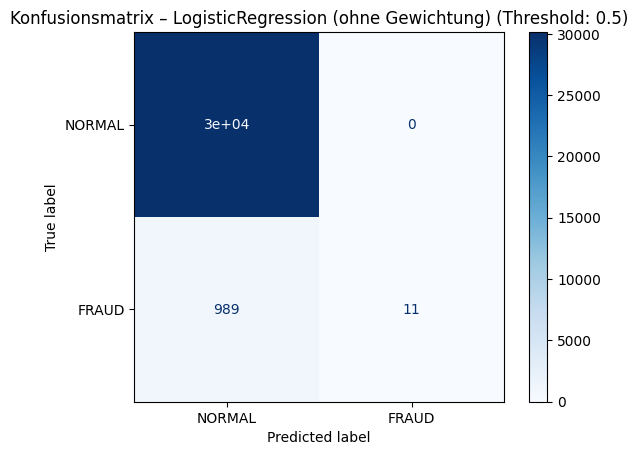


📈 ROC-AUC: 0.8128


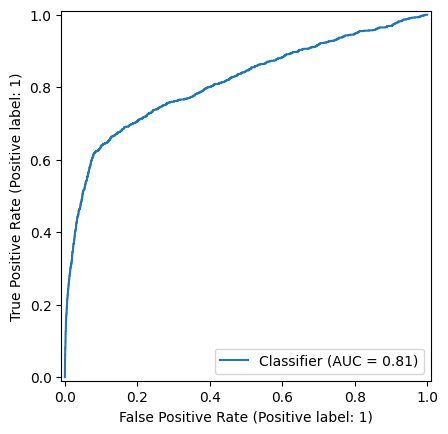

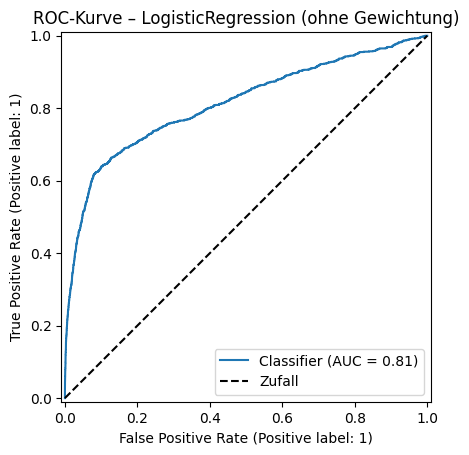

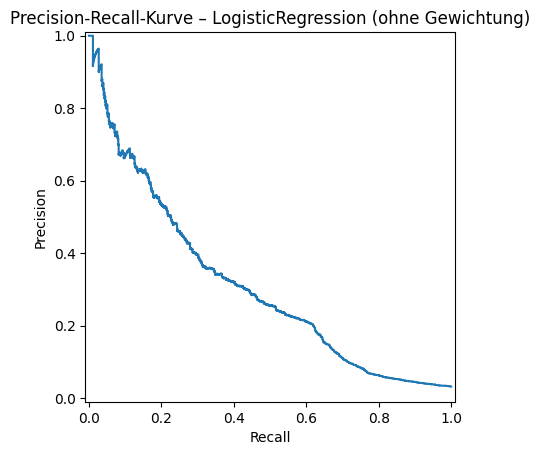


🎯 Wert der Zielfunktion: -7689.86


🔍 Modell: RandomForestClassifier (ohne Gewichtung)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.68      0.18      0.28      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.59      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30056    83]
 [  823   177]]


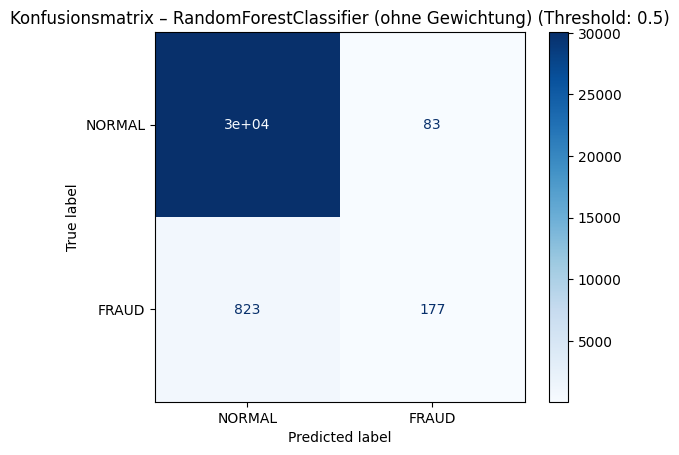


📈 ROC-AUC: 0.8125


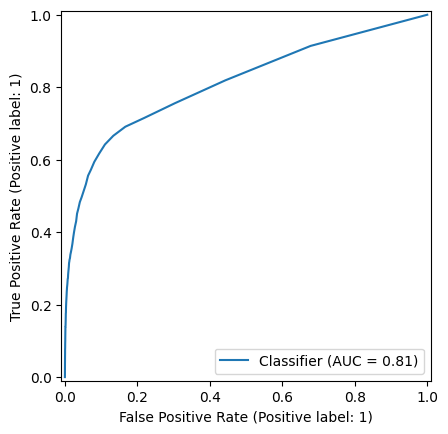

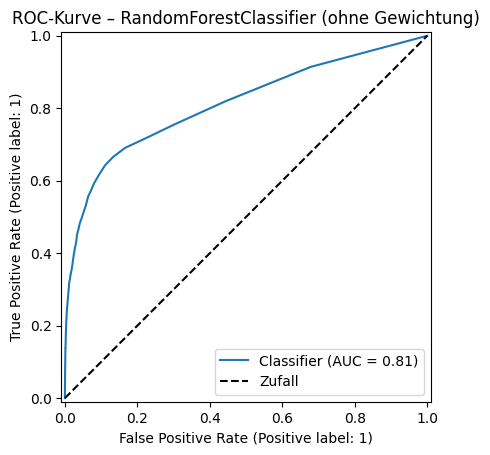

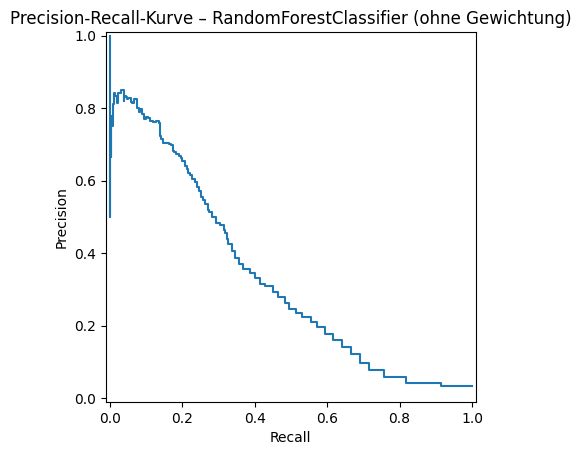


🎯 Wert der Zielfunktion: -6134.93


🔍 Modell: HistGradientBoostingClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.69      0.16      0.25      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.58      0.62     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30070    69]
 [  844   156]]


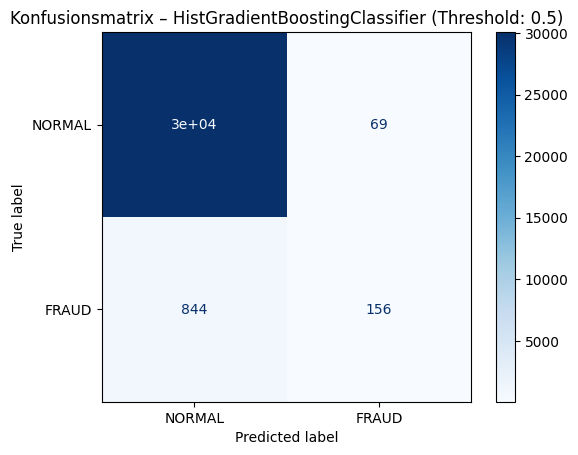


📈 ROC-AUC: 0.8337


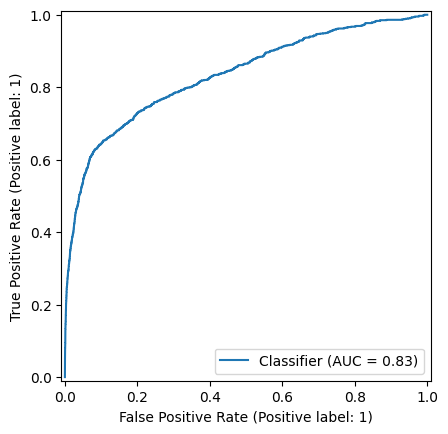

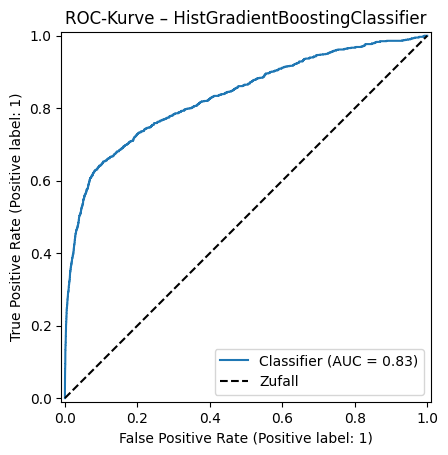

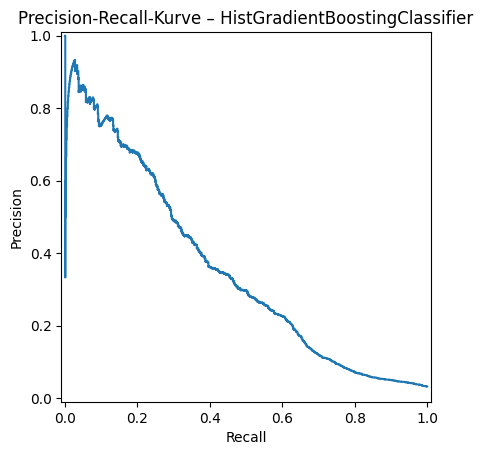


🎯 Wert der Zielfunktion: -6241.90


🔍 Modell: GradientBoostingClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.15      0.25      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.57      0.62     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30077    62]
 [  848   152]]


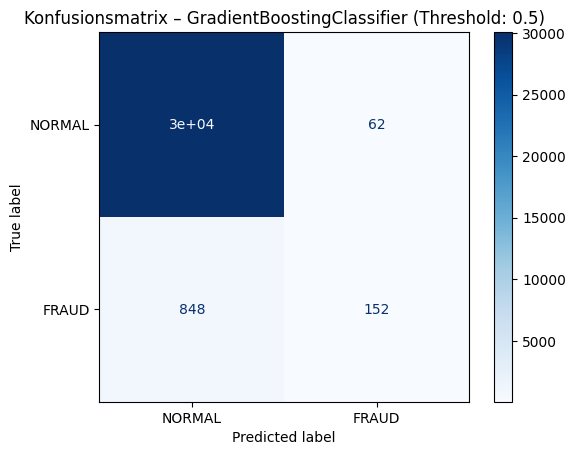


📈 ROC-AUC: 0.8415


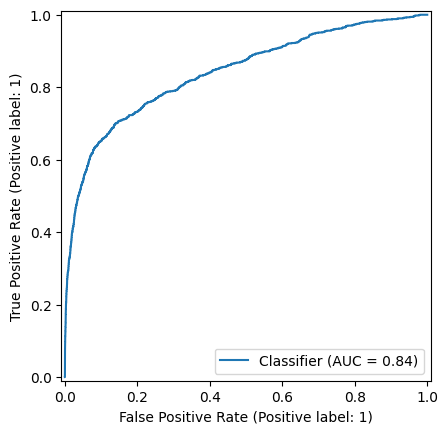

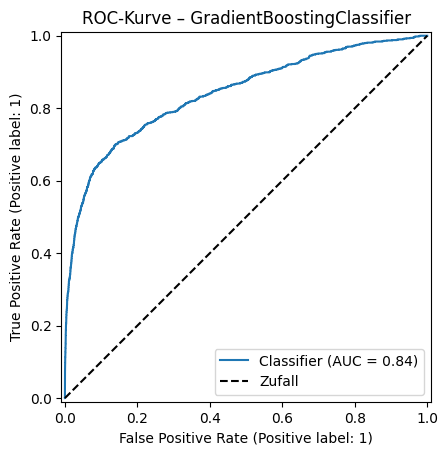

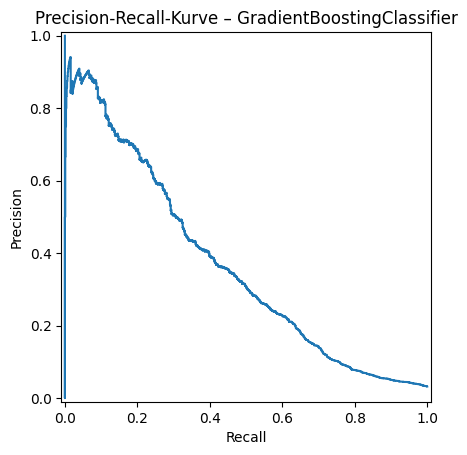


🎯 Wert der Zielfunktion: -6243.11


🔍 Modell: XGBClassifier (ungewichtet)


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:19:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.98     30139
       FRAUD       0.60      0.18      0.27      1000

    accuracy                           0.97     31139
   macro avg       0.78      0.59      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30018   121]
 [  822   178]]


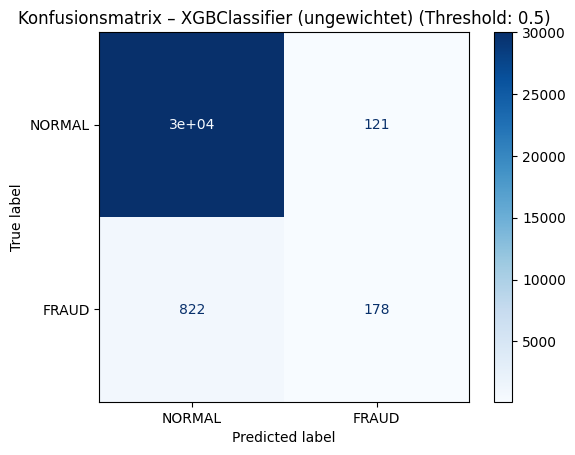


📈 ROC-AUC: 0.8214


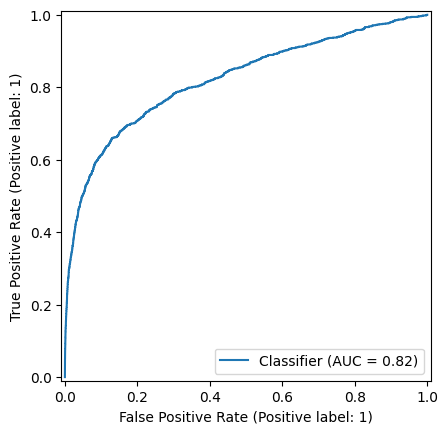

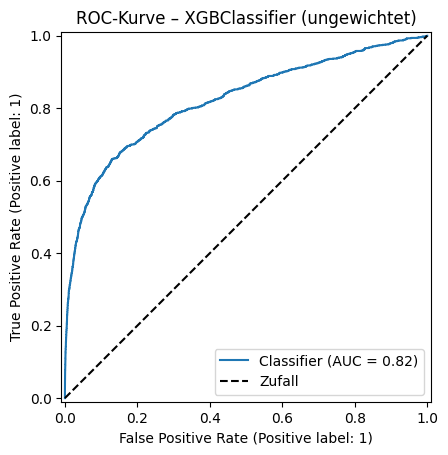

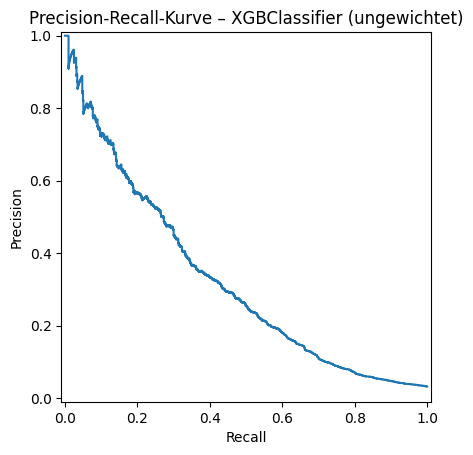


🎯 Wert der Zielfunktion: -6439.89


🔍 Modell: LGBMClassifier
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.72      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30066    73]
 [  816   184]]


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


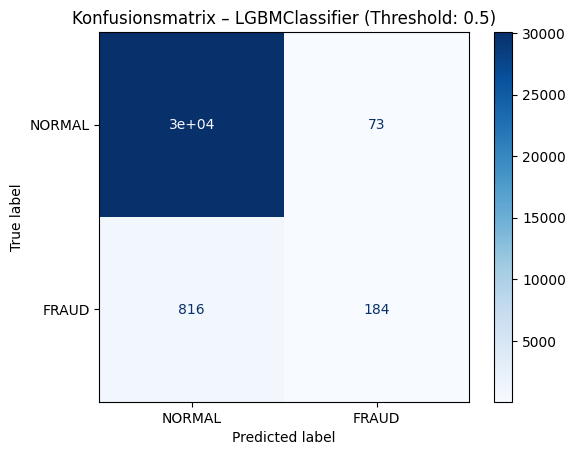


📈 ROC-AUC: 0.8353


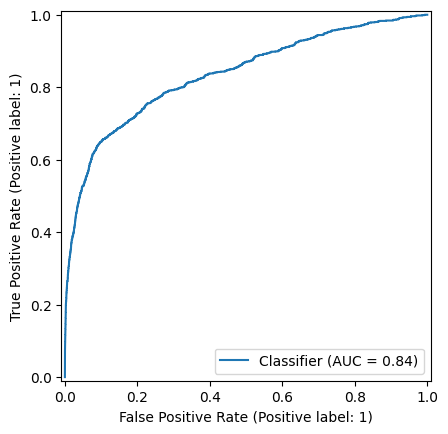

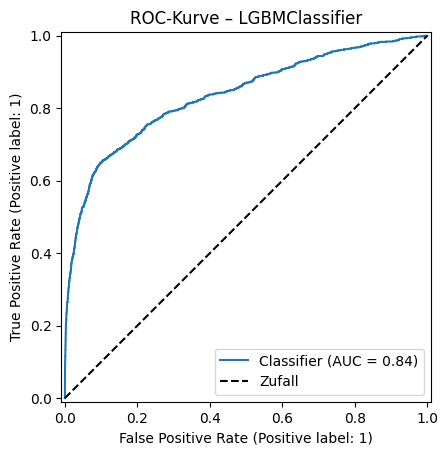

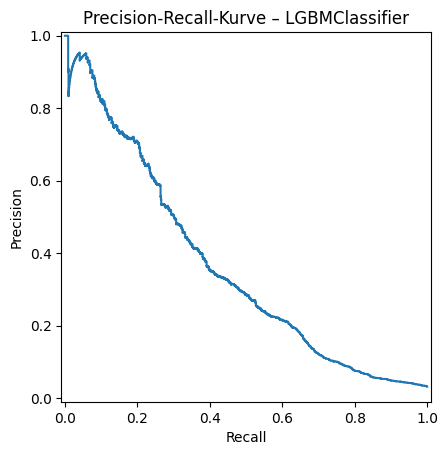


🎯 Wert der Zielfunktion: -5879.60


🔍 Modell: CatBoostClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.98     30139
       FRAUD       0.65      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.81      0.59      0.64     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30039   100]
 [  817   183]]


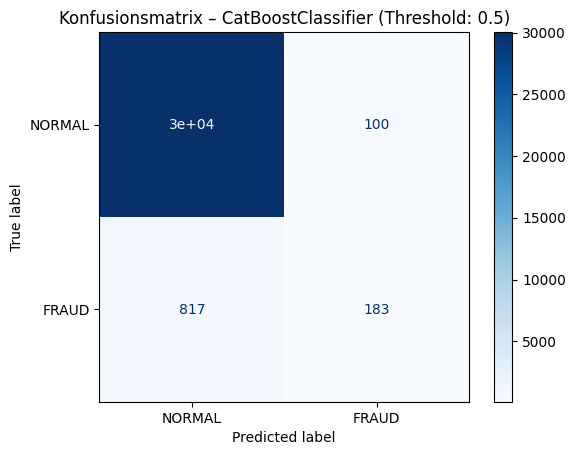


📈 ROC-AUC: 0.8268


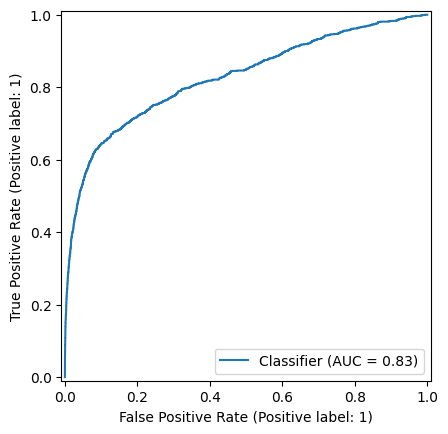

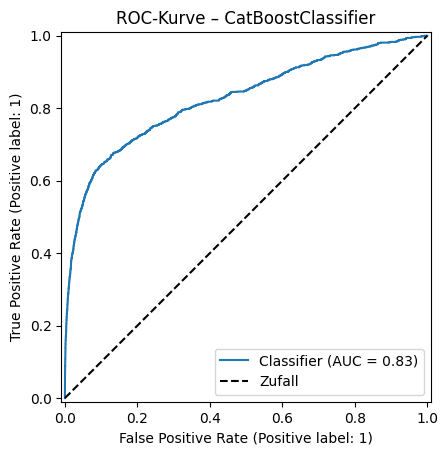

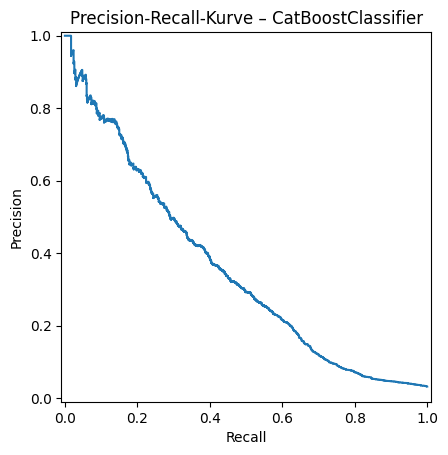


🎯 Wert der Zielfunktion: -6180.03


🔍 Modell: BalancedRandomForestClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.91      0.95     30139
       FRAUD       0.19      0.64      0.29      1000

    accuracy                           0.90     31139
   macro avg       0.59      0.78      0.62     31139
weighted avg       0.96      0.90      0.93     31139


🔲 Konfusionsmatrix:
[[27422  2717]
 [  358   642]]


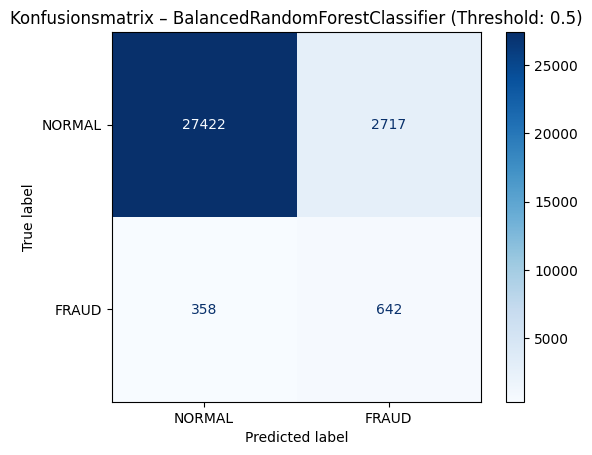


📈 ROC-AUC: 0.8288


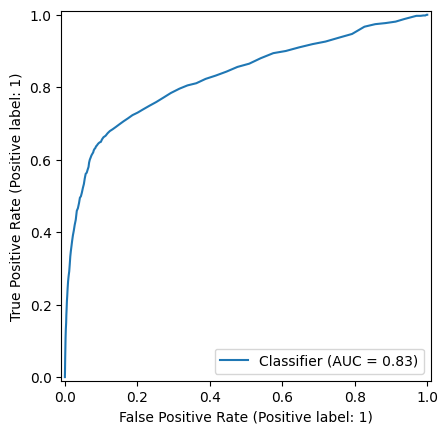

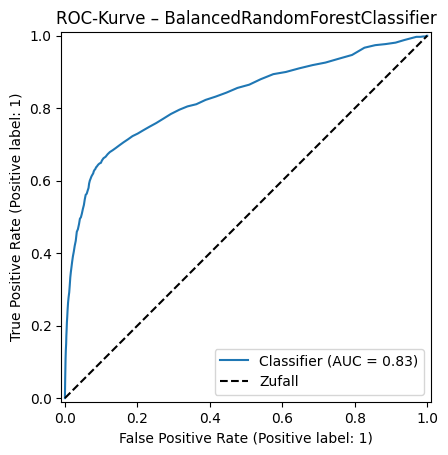

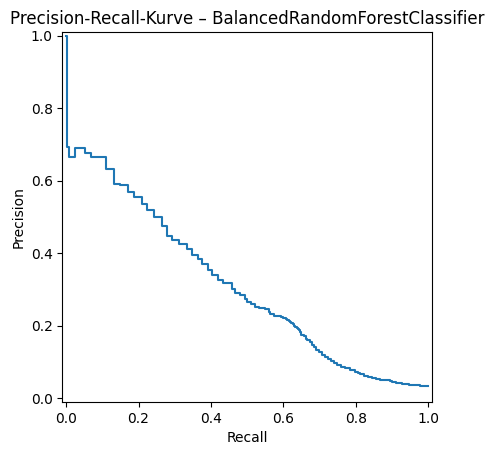


🎯 Wert der Zielfunktion: -26642.40


🔍 Modell: RUSBoostClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.92      0.95     30139
       FRAUD       0.20      0.62      0.31      1000

    accuracy                           0.91     31139
   macro avg       0.60      0.77      0.63     31139
weighted avg       0.96      0.91      0.93     31139


🔲 Konfusionsmatrix:
[[27744  2395]
 [  384   616]]


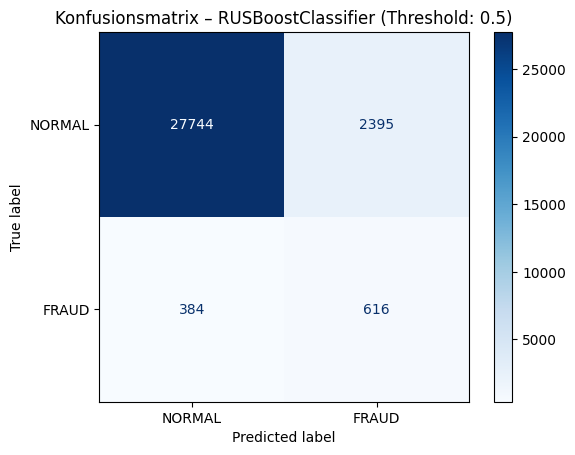


📈 ROC-AUC: 0.7683


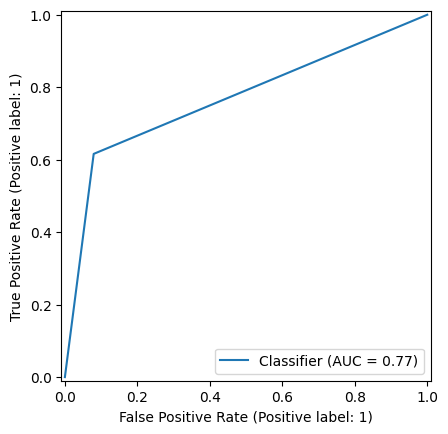

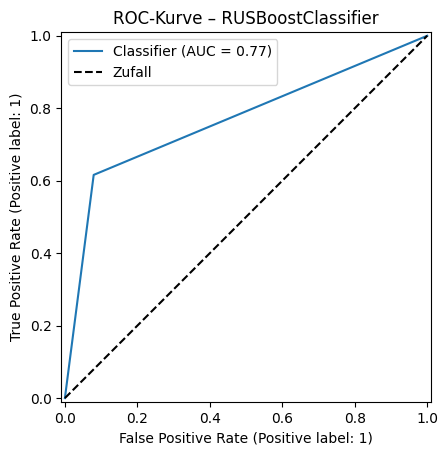

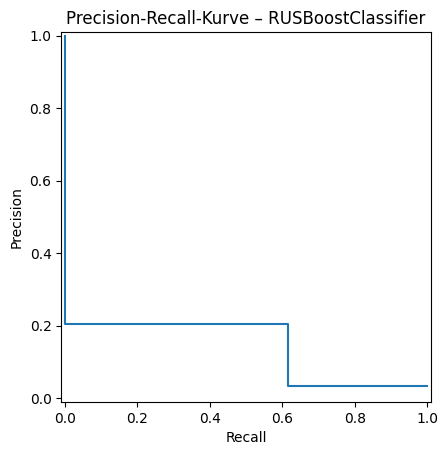


🎯 Wert der Zielfunktion: -23832.55


In [15]:
# Logistic Regression (ohne Gewichtung)
evaluate_model_with_curves(
    model=LogisticRegression(solver='liblinear', random_state=42),
    model_name="LogisticRegression (ohne Gewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# Random Forest (ohne Gewichtung)
evaluate_model_with_curves(
    model=RandomForestClassifier(n_estimators=100, random_state=42),
    model_name="RandomForestClassifier (ohne Gewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# HistGradientBoosting (hat kein class_weight, bleibt wie er ist)
evaluate_model_with_curves(
    model=HistGradientBoostingClassifier(random_state=42),
    model_name="HistGradientBoostingClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# Gradient Boosting (klassisch von sklearn)
evaluate_model_with_curves(
    model=GradientBoostingClassifier(random_state=42),
    model_name="GradientBoostingClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# XGBClassifier
evaluate_model_with_curves(
    model=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    model_name="XGBClassifier (ungewichtet)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# LightGBM
evaluate_model_with_curves(
    model=LGBMClassifier(random_state=42),
    model_name="LGBMClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# CatBoost (funktioniert out-of-the-box)
evaluate_model_with_curves(
    model=CatBoostClassifier(verbose=0, random_state=42),
    model_name="CatBoostClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# BalancedRandomForest (imbalanced-learn)
evaluate_model_with_curves(
    model=BalancedRandomForestClassifier(random_state=42),
    model_name="BalancedRandomForestClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# RUSBoost (imbalanced-learn)
evaluate_model_with_curves(
    model=RUSBoostClassifier(random_state=42),
    model_name="RUSBoostClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

Nach dem ersten Training meiner ausgewählten Modelle zeigten sich sehr typische Effekte, die bei einer stark unbalancierten Klassifikationsaufgabe häufig auftreten:

**Klassische Accuracy wenig aussagekräftig**
Bei fast allen Modellen lag die klassische Genauigkeit (Accuracy) bei etwa 97%. Das klingt auf den ersten Blick sehr gut, ist aber in diesem Fall wenig hilfreich, da diese hohe Accuracy fast ausschließlich auf der korrekten Klassifizierung der Mehrheitsklasse („NORMAL“) beruht. Hier zeigt sich der typische Imbalance-Effekt: Das Modell lernt vor allem, die häufige Klasse gut vorherzusagen, hat aber Schwierigkeiten mit der seltenen Klasse („FRAUD“).

**Recall für FRAUD als entscheidende Kennzahl**
Entscheidend für meine Aufgabenstellung ist der Recall der Klasse FRAUD, da insbesondere die False Negatives hohe wirtschaftliche Kosten verursachen. Hier zeigen sich deutliche Unterschiede zwischen den Modellen.
Die klassischen Modelle ohne spezielle Maßnahmen gegen Imbalance erreichen nur sehr niedrige Recall-Werte (ca. 15–18%). Lediglich BalancedRandomForest und RUSBoost konnten den Recall deutlich steigern (über 60%), allerdings mit einem klaren Nachteil bei den False Positives.

**Trade-off zwischen Recall und Präzision**
Die beiden Sampling-basierten Modelle BalancedRandomForest und RUSBoost erhöhen zwar den Recall deutlich, verursachen dafür aber auch sehr viele False Positives (FP: 2717 bzw. 2395). Da in meiner Zielfunktion False Positives wirtschaftlich stark negativ bewertet werden, ist dieser Effekt problematisch.

**Bewertung anhand der Zielfunktion**
Um die Modelle ganzheitlich zu bewerten, habe ich meine spezifische Zielfunktion angewendet
Obwohl BalancedRandomForest und RUSBoost den Recall stark verbessern, verschlechtern sich die wirtschaftlichen Gesamtkosten durch die vielen False Positives erheblich. Das LGBMClassifier-Modell erreicht hingegen den besten Kompromiss zwischen Sensitivität und Präzision und liefert in der Kostenfunktion den besten Gesamtnutzen.

**Zwischenfazit:**
Die ersten Testergebnisse zeigen sehr deutlich den Zielkonflikt zwischen Recall und wirtschaftlichem Nutzen. Sampling-basierte Verfahren wie BalancedRandomForest und RUSBoost sind zwar aus klassifikatorischer Sicht gut für die Fraud-Erkennung, aber für den praktischen Einsatz in meinem Anwendungsfall wirtschaftlich ungeeignet.
Aktuell stellt der **LGBMClassifier** den besten Modellkandidaten für die weitere Modelloptimierung und Nutzbarmachung dar.


### 3.2. Klassen invers zur Häufigkeit gewichtet ('class_weight='balanced')

Da der Datensatz ein starkes Ungleichgewicht zwischen den Klassen aufweist (ca. 97% NORMAL vs. ca. 3% FRAUD), wurde in einer zweiten Optimierungsrunde gezielt versucht, die Erkennung der Minderheitsklasse FRAUD zu verbessern. Dafür wurden verschiedene Imbalance-Strategien abhängig vom jeweiligen Modelltyp eingesetzt.

**Die Anpassungen im Überblick:**

•	Modelle mit class_weight-Unterstützung
Bei Modellen wie LogisticRegression, RandomForest und HistGradientBoosting wurde der Parameter class_weight='balanced' gesetzt. Dadurch wird das Gewicht der Klassen automatisch entsprechend ihrer Häufigkeit angepasst, sodass Fehlklassifikationen in der Minderheitsklasse stärker gewichtet werden.

•	Boosting-Algorithmen (XGBoost, LightGBM, CatBoost)
Hier wurde der Parameter scale_pos_weight verwendet, der das Verhältnis zwischen Mehrheits- und Minderheitsklasse explizit berücksichtigt. So wird dem Modell signalisiert, dass Fehler in der FRAUD-Klasse stärker ins Gewicht fallen sollen.

•	Spezialisierte Sampling-Algorithmen (BalancedRandomForest, RUSBoost)
Diese Modelle beinhalten eigene Mechanismen zum Ausgleich der Klassenverteilung. BalancedRandomForest arbeitet mit einer gezielten Unterabtastung der Mehrheitsklasse innerhalb der Bootstrap-Samples, während RUSBoost eine Kombination aus aggressivem Downsampling und Boosting nutzt.

Das Ziel dieser Anpassungen war es, den Recall für FRAUD gezielt zu erhöhen, also möglichst viele tatsächliche Fraud-Fälle korrekt zu erkennen. Gleichzeitig sollte die Gesamtperformance jedoch nicht durch eine zu starke Zunahme an False Positives verschlechtert werden.


In [17]:
#  # Verhältnis berechnen
neg_count = len(y_train[y_train == 0])
pos_count = len(y_train[y_train == 1])
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 30.14




🔍 Modell: LogisticRegression (mit Klassengewichtung)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.90      0.94     30139
       FRAUD       0.18      0.64      0.28      1000

    accuracy                           0.89     31139
   macro avg       0.58      0.77      0.61     31139
weighted avg       0.96      0.89      0.92     31139


🔲 Konfusionsmatrix:
[[27208  2931]
 [  358   642]]


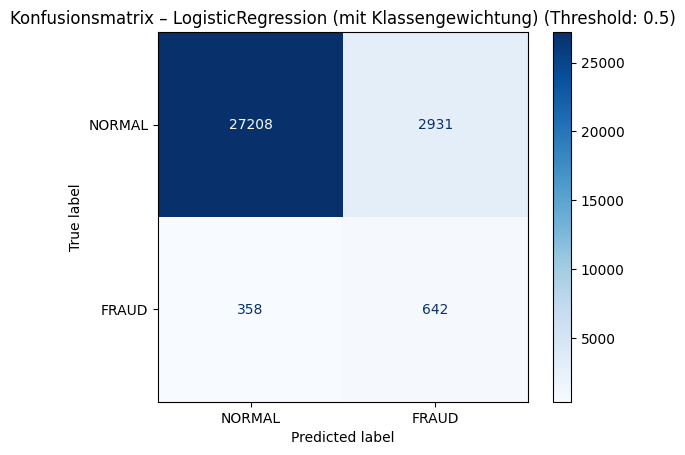


📈 ROC-AUC: 0.8276


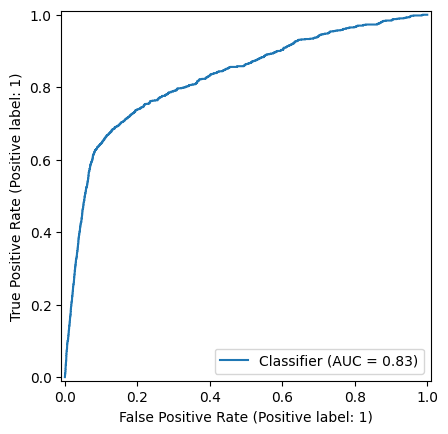

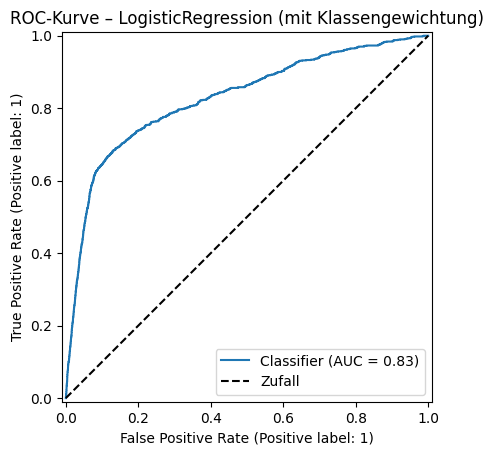

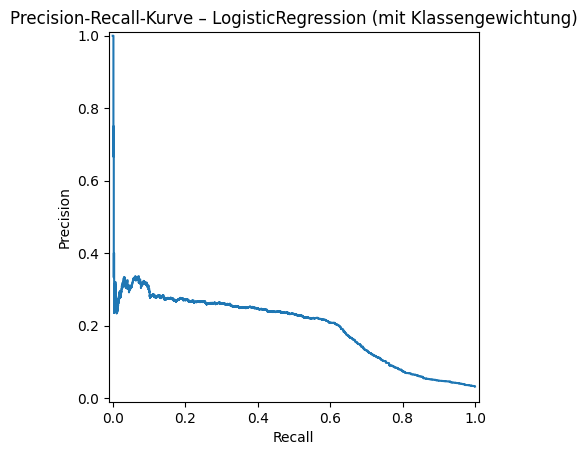


🎯 Wert der Zielfunktion: -28792.58


🔍 Modell: RandomForestClassifier (mit Klassengewichtung)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.98     30139
       FRAUD       0.70      0.14      0.23      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.57      0.61     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30081    58]
 [  863   137]]


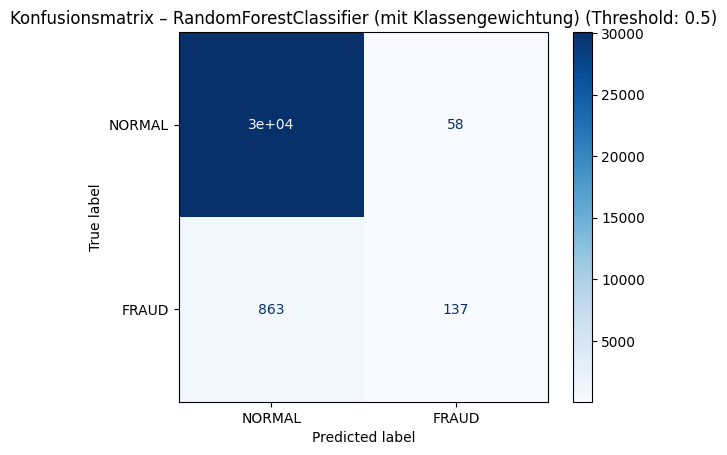


📈 ROC-AUC: 0.8050


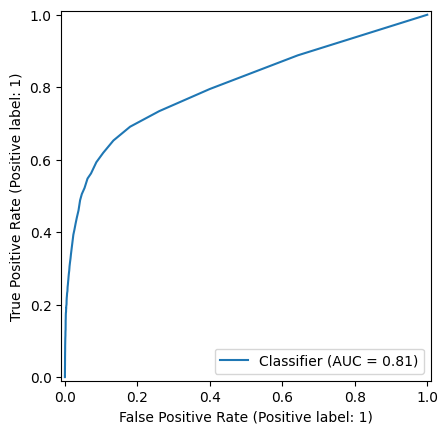

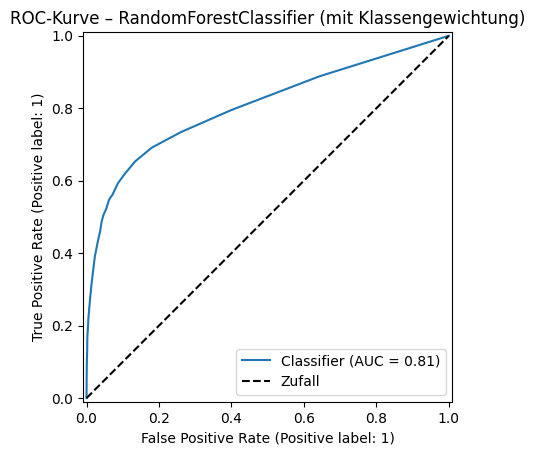

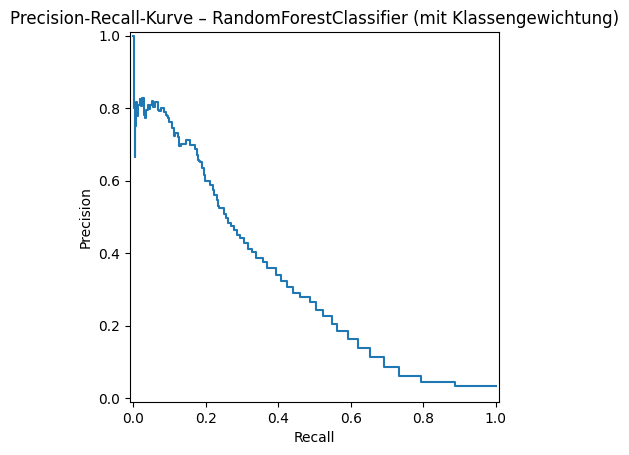


🎯 Wert der Zielfunktion: -6409.00


🔍 Modell: HistGradientBoostingClassifier (mit Klassengewichtung)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.90      0.94     30139
       FRAUD       0.18      0.65      0.28      1000

    accuracy                           0.89     31139
   macro avg       0.58      0.78      0.61     31139
weighted avg       0.96      0.89      0.92     31139


🔲 Konfusionsmatrix:
[[27220  2919]
 [  352   648]]


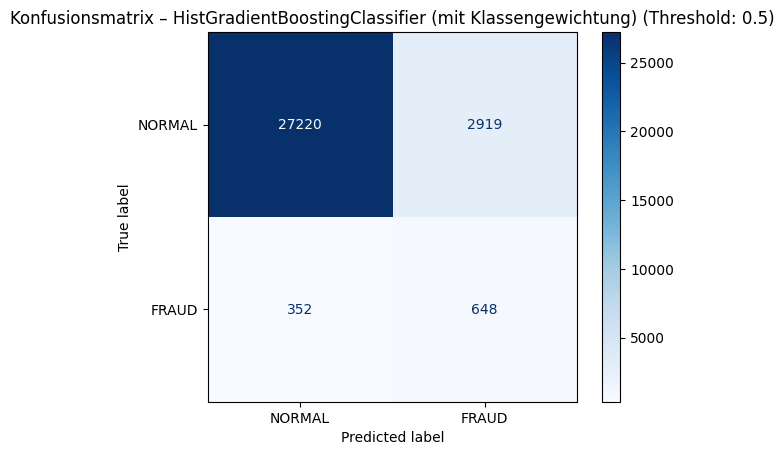


📈 ROC-AUC: 0.8362


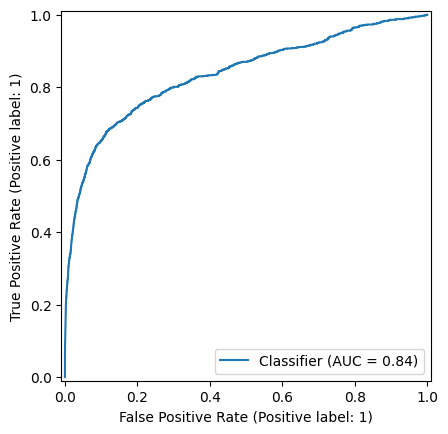

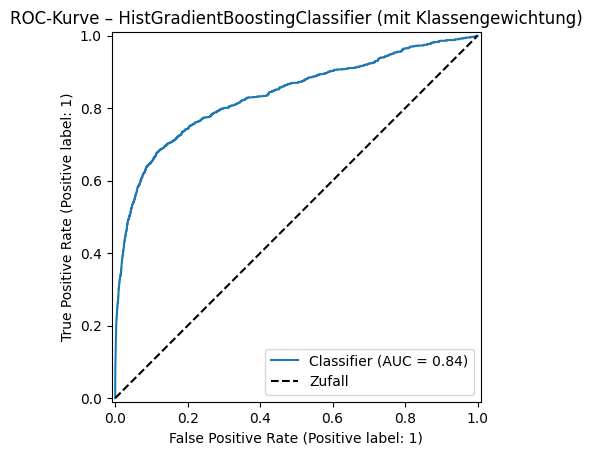

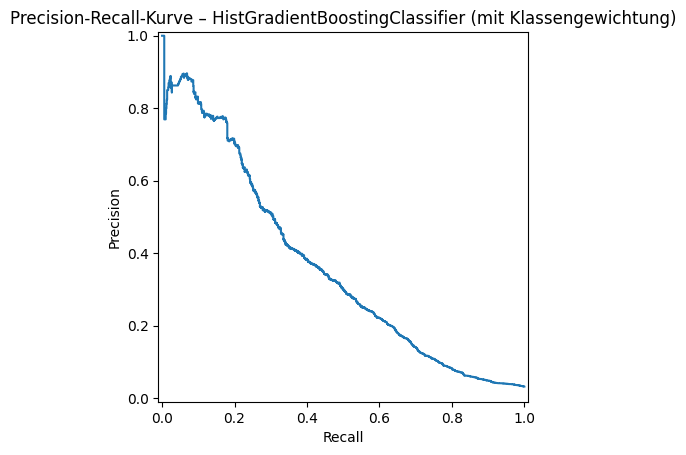


🎯 Wert der Zielfunktion: -28586.37


🔍 Modell: GradientBoostingClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.15      0.25      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.57      0.62     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30077    62]
 [  848   152]]


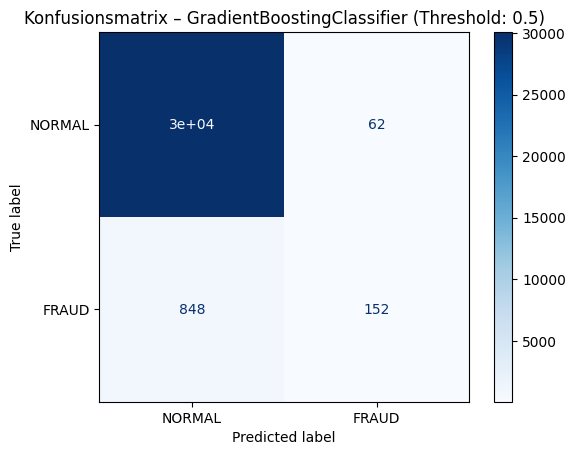


📈 ROC-AUC: 0.8415


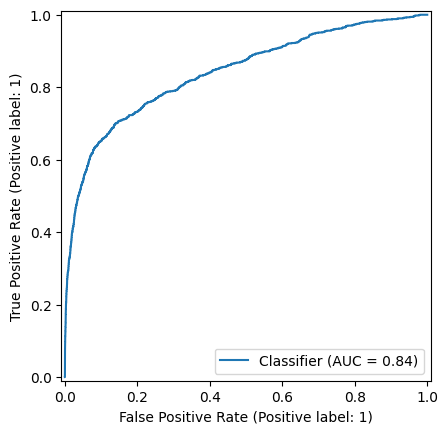

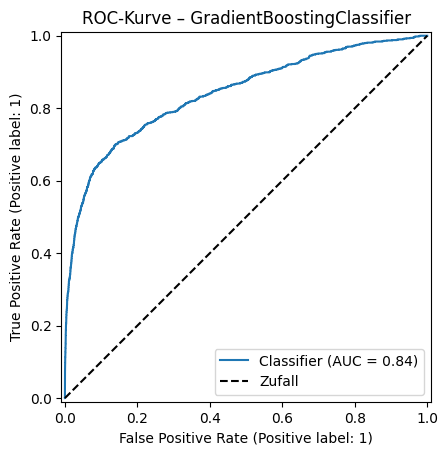

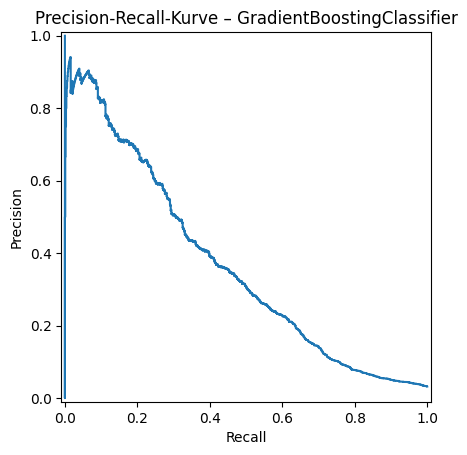


🎯 Wert der Zielfunktion: -6243.11


🔍 Modell: XGBClassifier (mit Klassengewichtung)


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:09:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.98      0.92      0.95     30139
       FRAUD       0.19      0.58      0.28      1000

    accuracy                           0.91     31139
   macro avg       0.59      0.75      0.62     31139
weighted avg       0.96      0.91      0.93     31139


🔲 Konfusionsmatrix:
[[27632  2507]
 [  422   578]]


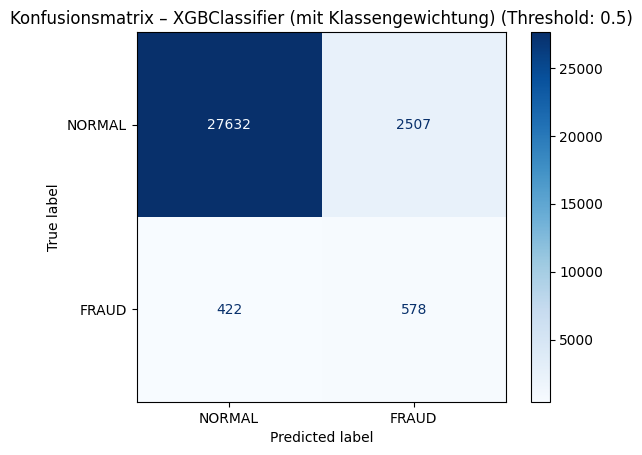


📈 ROC-AUC: 0.7982


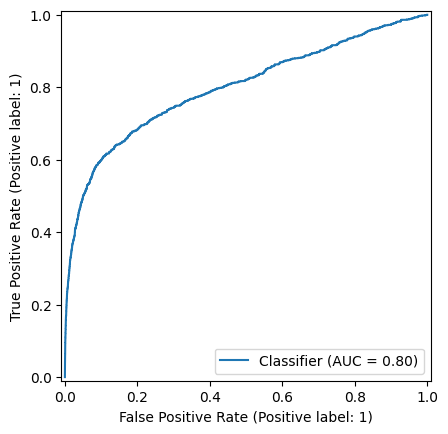

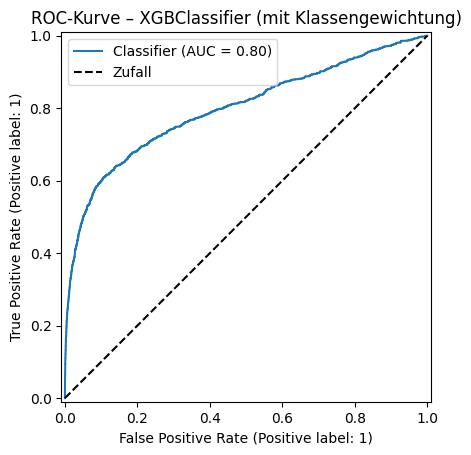

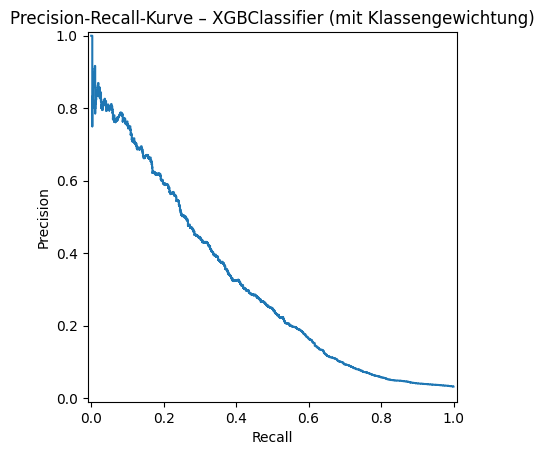


🎯 Wert der Zielfunktion: -25179.26


🔍 Modell: LGBMClassifier (mit Klassengewichtung)
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015307 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.90      0.94     30139
       FRAUD       0.18      0.65      0.28      1000

    accuracy                           0.89     31139
   macro avg       0.58      0.78      0.61     31139
weighted avg       0.96      0.89      0.92     31139


🔲 Konfusionsmatrix:
[[27192  2947]
 [  352   648]]


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


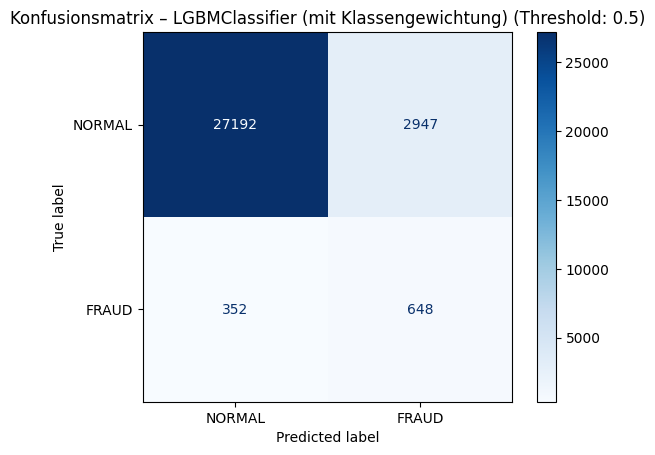


📈 ROC-AUC: 0.8285


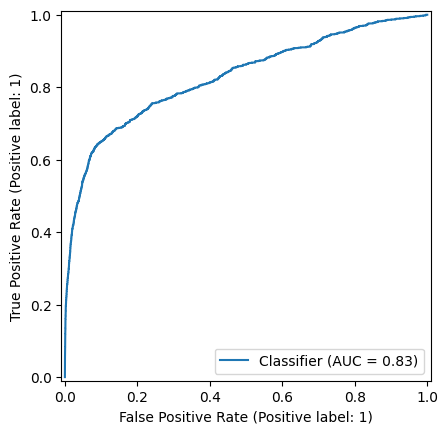

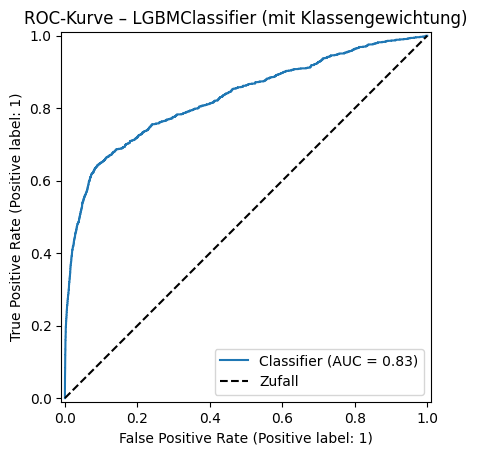

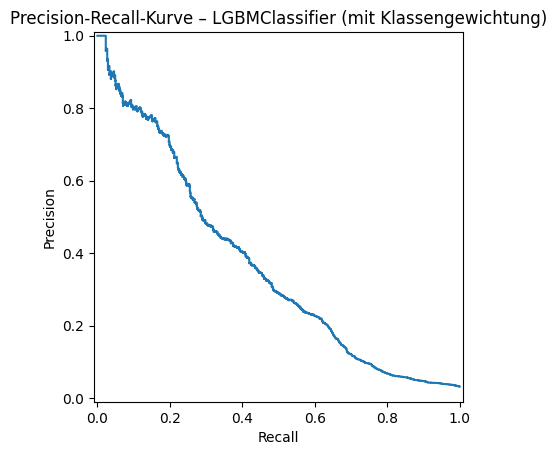


🎯 Wert der Zielfunktion: -28854.82


🔍 Modell: CatBoostClassifier (mit Klassengewichtung)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.93      0.95     30139
       FRAUD       0.21      0.58      0.31      1000

    accuracy                           0.92     31139
   macro avg       0.60      0.75      0.63     31139
weighted avg       0.96      0.92      0.93     31139


🔲 Konfusionsmatrix:
[[27920  2219]
 [  419   581]]


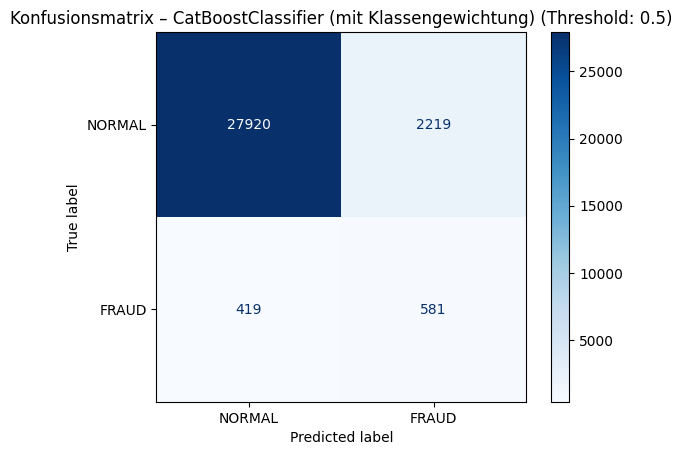


📈 ROC-AUC: 0.8173


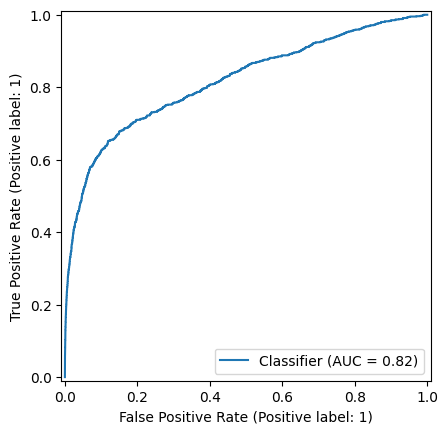

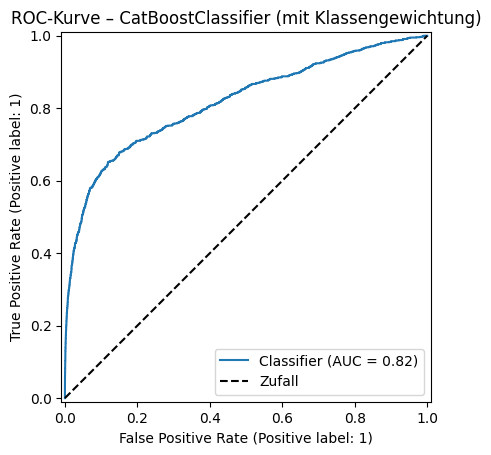

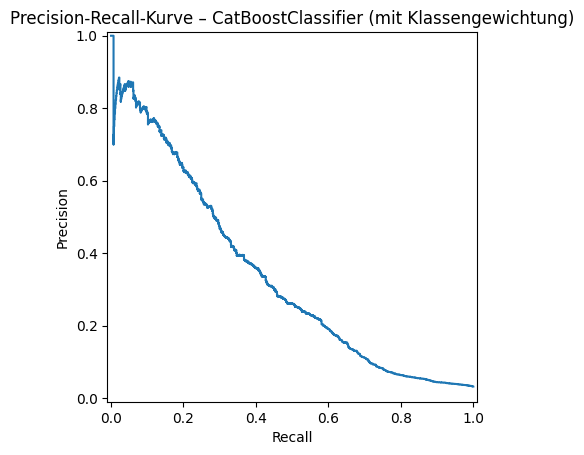


🎯 Wert der Zielfunktion: -22374.97


🔍 Modell: BalancedRandomForestClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.91      0.95     30139
       FRAUD       0.19      0.64      0.29      1000

    accuracy                           0.90     31139
   macro avg       0.59      0.78      0.62     31139
weighted avg       0.96      0.90      0.93     31139


🔲 Konfusionsmatrix:
[[27422  2717]
 [  358   642]]


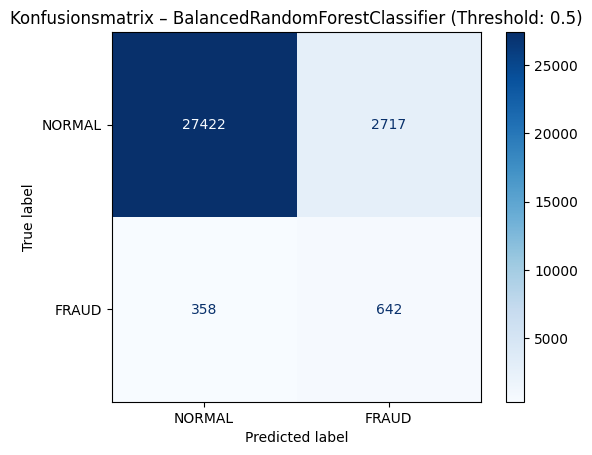


📈 ROC-AUC: 0.8288


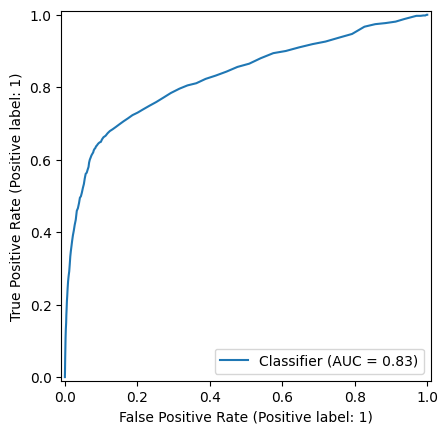

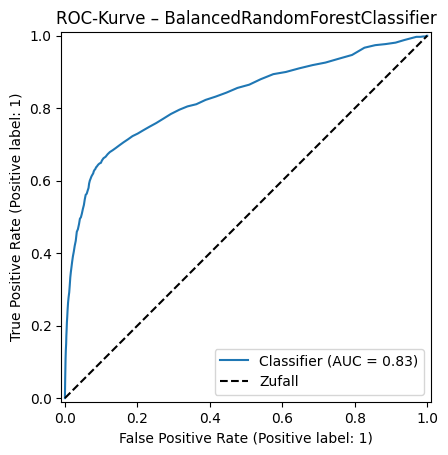

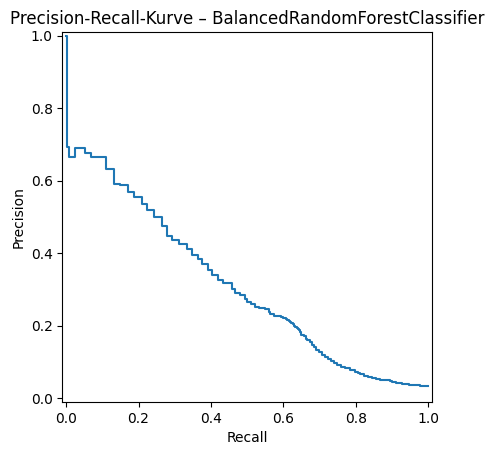


🎯 Wert der Zielfunktion: -26642.40


🔍 Modell: RUSBoostClassifier

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.92      0.95     30139
       FRAUD       0.20      0.62      0.31      1000

    accuracy                           0.91     31139
   macro avg       0.60      0.77      0.63     31139
weighted avg       0.96      0.91      0.93     31139


🔲 Konfusionsmatrix:
[[27744  2395]
 [  384   616]]


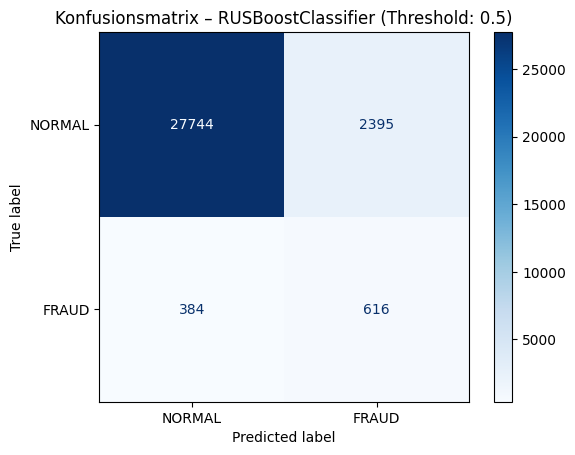


📈 ROC-AUC: 0.7683


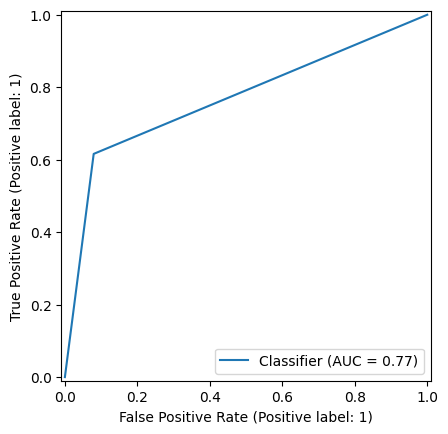

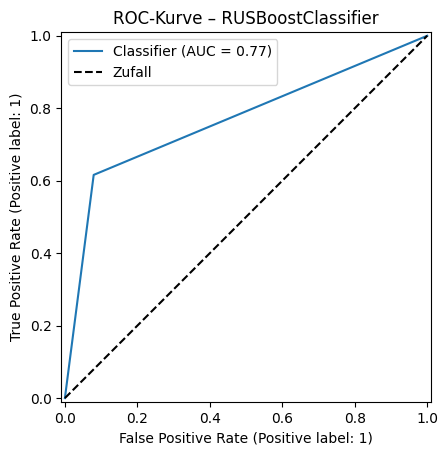

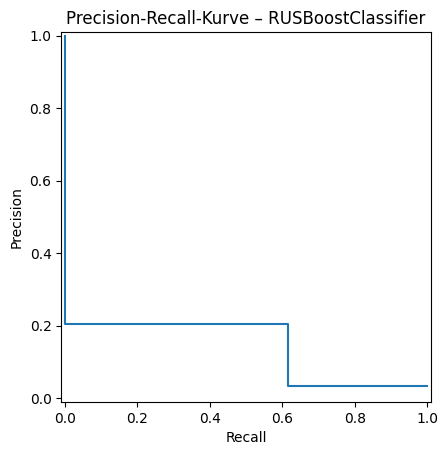


🎯 Wert der Zielfunktion: -23832.55


In [19]:
# Logistic Regression (mit Gewichtung)
evaluate_model_with_curves(
    model=LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42),
    model_name="LogisticRegression (mit Klassengewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# Random Forest (mit Gewichtung)
evaluate_model_with_curves(
    model=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    model_name="RandomForestClassifier (mit Klassengewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# HistGradientBoosting (hat kein class_weight, bleibt wie er ist)
evaluate_model_with_curves(
    model=HistGradientBoostingClassifier(random_state=42, class_weight='balanced'),
    model_name="HistGradientBoostingClassifier (mit Klassengewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# Gradient Boosting (klassisch von sklearn)
evaluate_model_with_curves(
    model=GradientBoostingClassifier(random_state=42),  # nutzt eigenes Sampling
    model_name="GradientBoostingClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# XGBClassifier
evaluate_model_with_curves(
    model=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss', 
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ),
    model_name="XGBClassifier (mit Klassengewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# LightGBM
evaluate_model_with_curves(
    model=LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42),
    model_name="LGBMClassifier (mit Klassengewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# CatBoost (funktioniert out-of-the-box)
evaluate_model_with_curves(
    model=CatBoostClassifier(scale_pos_weight=scale_pos_weight, verbose=0, random_state=42),
    model_name="CatBoostClassifier (mit Klassengewichtung)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# BalancedRandomForest (imbalanced-learn)
evaluate_model_with_curves(
    model=BalancedRandomForestClassifier(random_state=42),  # nutzt eigenes Sampling
    model_name="BalancedRandomForestClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# RUSBoost (imbalanced-learn)
evaluate_model_with_curves(
    model=RUSBoostClassifier(random_state=42),  # nutzt eigenes Sampling
    model_name="RUSBoostClassifier",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

**Ergebnis:**
**Klassische Metriken weiterhin begrenzt aussagekräftig**
Auch nach der Imbalance-Anpassung liefern viele Modelle sehr hohe Accuracy-Werte (teils 97%). Diese Werte spiegeln aber vorrangig die korrekte Klassifikation der Mehrheitsklasse wider und sagen wenig über die Leistung bei der wichtigen FRAUD-Klasse aus.

**Recall für FRAUD bleibt zentral**
Der Recall-Wert für FRAUD unterscheidet sich weiterhin deutlich zwischen den Modellen. Auffällig ist, dass BalancedRandomForestClassifier, HistGradientBoostingClassifier, LGBMClassifier und LogisticRegression nun relativ ähnliche Recall-Werte (ca. 62–65%) erreichen, während RandomForest und GradientBoostingClassifier trotz Imbalance-Anpassung weiterhin kaum FRAUD-Fälle erkennen (Recall < 0.15).

**False Positives als Kostenfaktor**
Die Steigerung des Recalls geht jedoch erneut bei mehreren Modellen mit deutlich mehr False Positives einher. Da False Positives in der Zielfunktion wirtschaftlich stark negativ gewichtet werden, schlägt sich dieser Effekt direkt in der Gesamtbewertung nieder.

**Bewertung über die Zielfunktion**
Die Gesamtnutzenbewertung anhand der betriebswirtschaftlichen Zielfunktion zeigt folgendes Ranking:
Modell	Zielfunktionswert
GradientBoostingClassifier	-6243,11 - 
RandomForestClassifier	-6409,00 - 
CatBoostClassifier	-22374,97 - 
RUSBoostClassifier	-23832,55 - 
XGBClassifier	-25179,26 - 
BalancedRandomForestClassifier	-26642,40 - 
HistGradientBoostingClassifier	-28586,37 - 
LogisticRegression	-28792,58 - 
LGBMClassifier	-28854,82 - 

**Zwischenfazit:**
Ein höherer Recall allein verbessert den wirtschaftlichen Gesamtnutzen nicht zwangsläufig. Die aktuelle Zielfunktion zeigt, dass zusätzliche False Positives stärker ins Gewicht fallen als einzelne nicht erkannte Fraud-Fälle. Modelle mit moderatem Recall, aber kontrollierten False Positives liefern hier den höchsten Gesamtnutzen. Die Modelle RandomForestClassifier und GradientBoostingClassifier liefern im aktuellen Stand den besten Kompromiss zwischen Erkennungsrate und wirtschaftlicher Belastung durch Fehlklassifikationen. Besonders RandomForestClassifier zeigt sich bisher als robuster Kandidat mit dem besten Zielfunktionswert (-6409,00).

### 3.3. Standardisierte Hyperparameter-Optimierung

In der dritten Optimierungsrunde optimiere ich alle Modelle systematisch über ihre wichtigsten Parameter, um faire und vergleichbare Ergebnisse zu erzielen. Für jedes Modell definiere ich sinnvolle Wertebereiche (z. B. Anzahl Bäume, Baumtiefe, Lernrate) und teste diese per zufälliger Parameterauswahl (Randomized Search). Die Bewertung erfolgt anhand der projektspezifischen wirtschaftlichen Zielfunktion, die die Kosten von Fehlern direkt berücksichtigt. Ziel ist es, die vielversprechendsten Modelle für die abschließende Feinoptimierung auszuwählen.

Bei der Hyperparameteroptimierung wurde RandomizedSearchCV mit n_jobs=1 ausgeführt, um Stabilitätsprobleme mit Pickling zu vermeiden. Die interne Parallelisierung der Modelle wurde bei allen unterstützenden Algorithmen über n_jobs=4 aktiviert, um die Mehrkern-Architektur effizient auszunutzen.

In [23]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# Cross-Validation Setup (wichtig für stabile Ergebnisse)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom Objective Function für RandomizedSearchCV (ohne Damage-Serie)
from sklearn.metrics import make_scorer, confusion_matrix

def custom_objective_simple(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    score = -50 * FN + 5 * TP - 10 * FP
    return score

custom_scorer = make_scorer(custom_objective_simple, greater_is_better=True)

# ========================================================
# RandomizedSearchCV SETUPS für alle Modelle
# ========================================================

# 1️⃣ Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

search_lr = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_lr.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_lr.fit(X_train, y_train)
print("Best LogisticRegression:", search_lr.best_params_)

# 2️⃣ Random Forest
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

search_rf = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_jobs=4, random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_rf.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_rf.fit(X_train, y_train)
print("Best RandomForestClassifier:", search_rf.best_params_)

# 3️⃣ Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0]
}

search_gb = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', GradientBoostingClassifier(random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_gb.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_gb.fit(X_train, y_train)
print("Best GradientBoostingClassifier:", search_gb.best_params_)

# 4️⃣ HistGradientBoosting
param_grid_hgb = {
    'max_iter': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [None, 10, 20]
}

search_hgb = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', HistGradientBoostingClassifier(random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_hgb.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_hgb.fit(X_train, y_train)
print("Best HistGradientBoostingClassifier:", search_hgb.best_params_)

# 5️⃣ XGBoost
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search_xgb = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier',
        XGBClassifier(n_jobs=4, use_label_encoder=False, eval_metric='logloss', random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_xgb.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_xgb.fit(X_train, y_train)
print("Best XGBClassifier:", search_xgb.best_params_)

# 6️⃣ LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [5, 10, 20]
}

search_lgbm = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', LGBMClassifier(n_jobs=4, random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_lgbm.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_lgbm.fit(X_train, y_train)
print("Best LGBMClassifier:", search_lgbm.best_params_)

# 7️⃣ CatBoost
param_grid_cat = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8]
}

search_cat = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', CatBoostClassifier(verbose=0, random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_cat.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_cat.fit(X_train, y_train)
print("Best CatBoostClassifier:", search_cat.best_params_)

# 8️⃣ BalancedRandomForest
param_grid_brf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, None]
}

search_brf = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', BalancedRandomForestClassifier(n_jobs=4, random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_brf.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_brf.fit(X_train, y_train)
print("Best BalancedRandomForestClassifier:", search_brf.best_params_)

# 9️⃣ RUSBoost
param_grid_rus = {
    'n_estimators': [50, 100, 300],
    'learning_rate': [0.01, 0.05, 0.1]
}

search_rus = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('classifier', 
        RUSBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), random_state=42))]),
    param_distributions={'classifier__' + k: v for k, v in param_grid_rus.items()},
    n_iter=10, scoring=custom_scorer, cv=cv, n_jobs=1, verbose=2, random_state=42
)

search_rus.fit(X_train, y_train)
print("Best RUSBoostClassifier:", search_rus.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=liblinear; total time=   4.7s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=liblinear; total time=   4.6s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=liblinear; total time=   4.8s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=liblinear; total time=   4.8s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=liblinear; total time=   4.5s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=lbfgs; total time=   4.4s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=lbfgs; total time=   4.5s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=lbfgs; total time=   4.6s
[CV] END classifier__C=0.01, classifier__max_iter=1000, classifier__solver=lbfgs; total time=   4.4s
[CV] END c

c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:47:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=7, classifier__n_estimators=500, classifier__subsample=0.7; total time=   8.4s


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:47:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.01, classifier__max_depth=7, classifier__n_estimators=500, classifier__subsample=0.7; total time=   9.1s


...

[CV] END classifier__learning_rate=0.01, classifier__max_depth=10, classifier__n_estimators=300, classifier__num_leaves=20; total time=   6.1s
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END classifier__max_depth=5, classifier__n_estimators=100; total time=   5.6s
[CV] END classifier__max_depth=5, classifier__n_estimators=100; total time=   5.4s
[CV] END classifier__max_depth=5, classifier__n_estimators=100; total time=   5.3s
[CV] END classifier__max_depth=5, classifier__n_estimators=100; total time=   5.2s
[CV] END classifier__max_depth=5, classifier__n_estimators=100; total time=   5.2s
[CV] END classifier__max_depth=5, classifier__n_estimators=300; total time=   7.6s
[CV] END classifier__max_depth=5, classifier__n_estimators=300; total time=   7.6s
[CV] END classifier__max_depth=5, classifier__n_estimators=300; total time=   7.6s
[CV] END classifier__max_depth=5, classifier__n_estimators=300; total time=   7.5s
[CV] END classifier__max_depth=5, classifier__n_estimators=300; total time=   7.6s
[CV] END classifier__max_depth=5, classifier__n_estimators=500; total time=   9.7s
[CV] END classifier__max_depth=5, classifier__n_estimators=500; total time=   9.8s
[CV]

c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END classifier__learning_rate=0.01, classifier__n_estimators=50; total time=   7.4s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=50; total time=   6.7s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=50; total time=   6.8s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=50; total time=   6.7s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=50; total time=   6.8s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=100; total time=   8.5s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=100; total time=   8.5s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=100; total time=   7.5s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=100; total time=   8.2s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=100; total time=   9.4s
[CV] END classifier__learning_rate=0.01, classifier__n_estimators=300; total time=   8.6s
[CV] END classi

Finalevaluation: Testset-Bewertung der besten Modelle



🔍 Modell: LogisticRegression (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.98     30139
       FRAUD       1.00      0.01      0.03      1000

    accuracy                           0.97     31139
   macro avg       0.98      0.51      0.51     31139
weighted avg       0.97      0.97      0.95     31139


🔲 Konfusionsmatrix:
[[30139     0]
 [  986    14]]


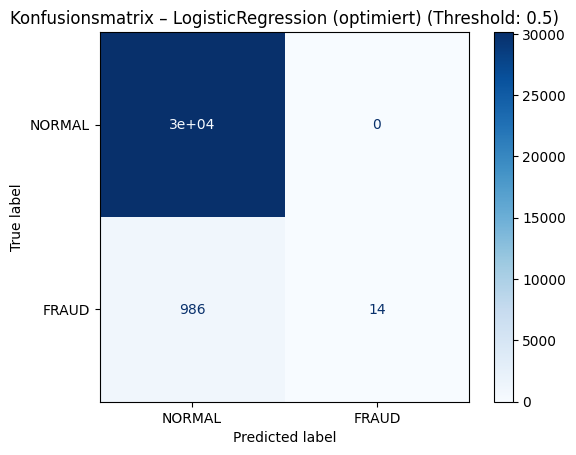


📈 ROC-AUC: 0.8192


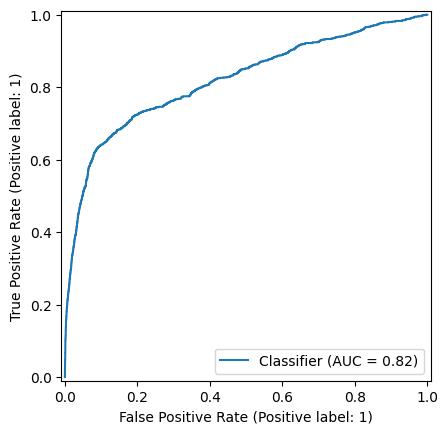

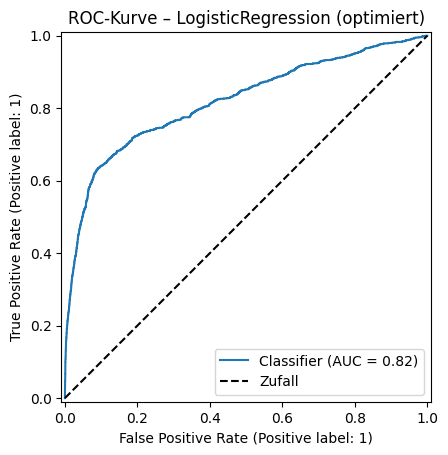

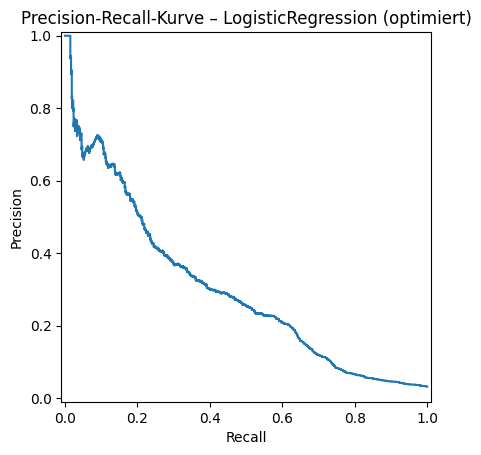


🎯 Wert der Zielfunktion: -7644.34


🔍 Modell: RandomForestClassifier (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.70      0.17      0.27      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.58      0.63     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30066    73]
 [  831   169]]


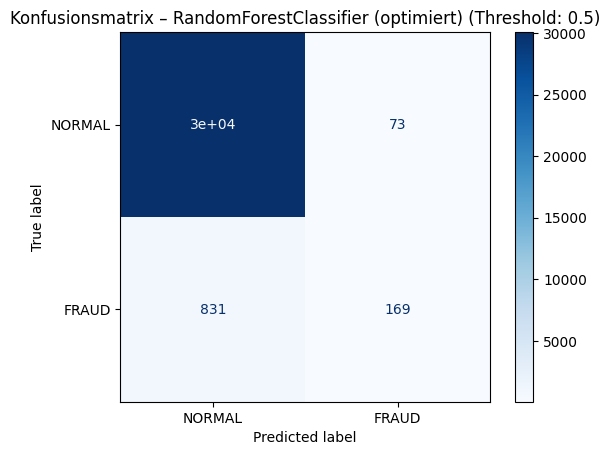


📈 ROC-AUC: 0.8188


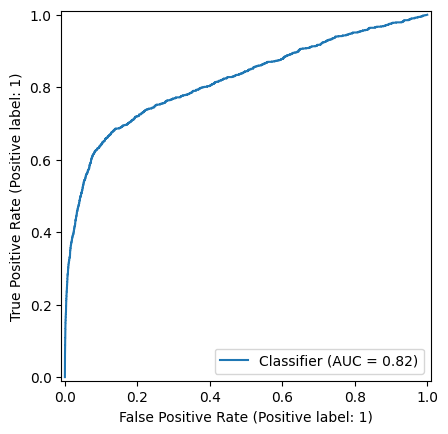

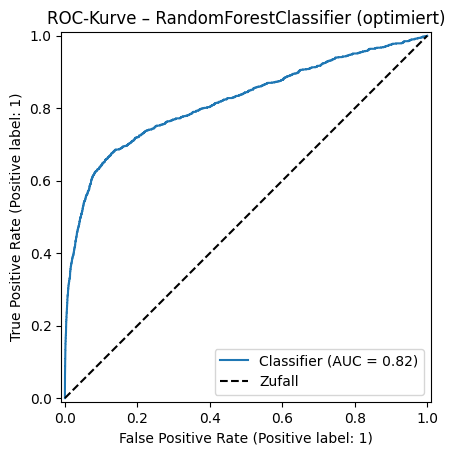

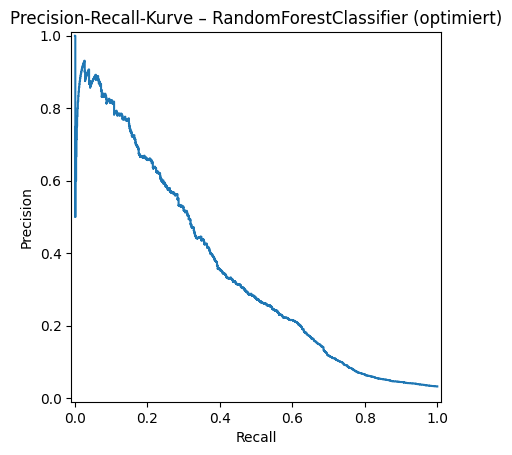


🎯 Wert der Zielfunktion: -6133.91


🔍 Modell: GradientBoostingClassifier (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.71      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30065    74]
 [  816   184]]


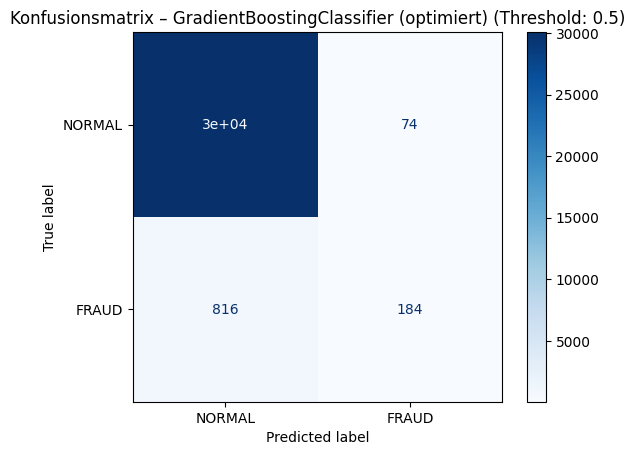


📈 ROC-AUC: 0.8404


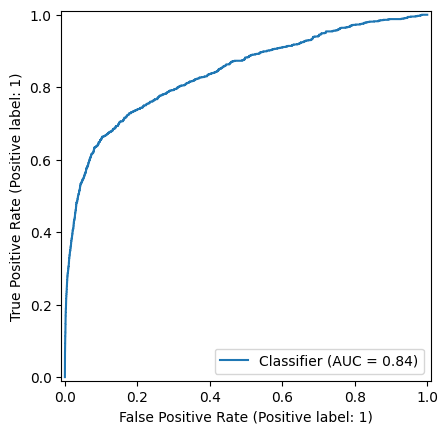

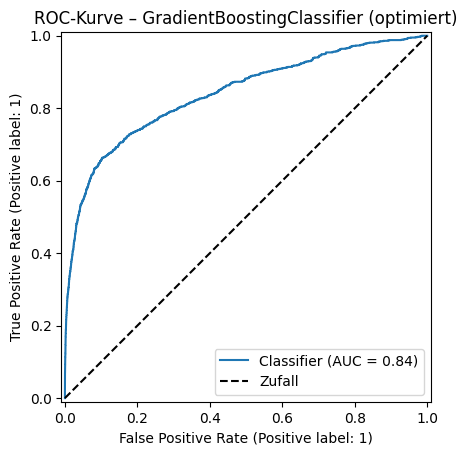

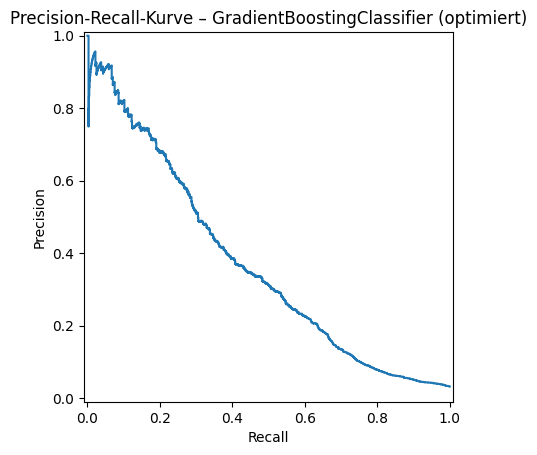


🎯 Wert der Zielfunktion: -5920.96


🔍 Modell: HistGradientBoostingClassifier (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.69      0.16      0.26      1000

    accuracy                           0.97     31139
   macro avg       0.83      0.58      0.62     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30067    72]
 [  842   158]]


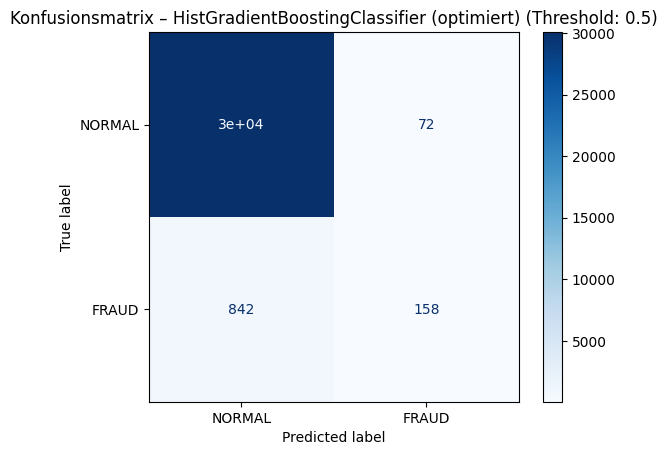


📈 ROC-AUC: 0.8337


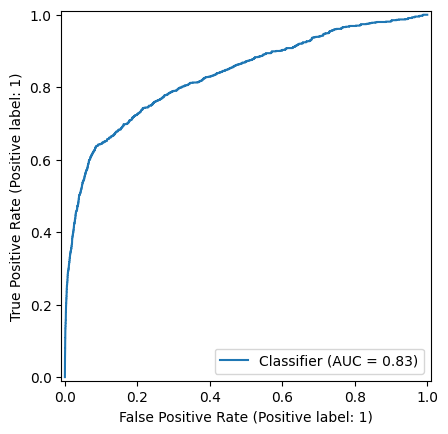

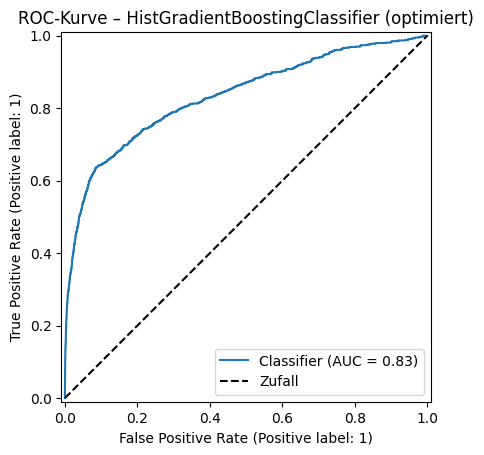

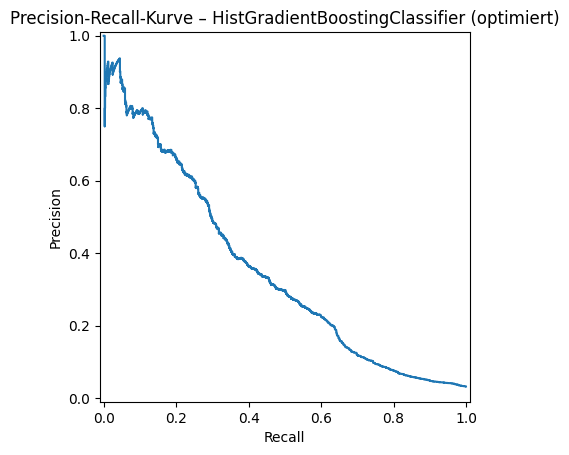


🎯 Wert der Zielfunktion: -6244.99


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:26:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)




🔍 Modell: XGBClassifier (optimiert)


c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:26:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.68      0.19      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.82      0.59      0.64     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30050    89]
 [  814   186]]


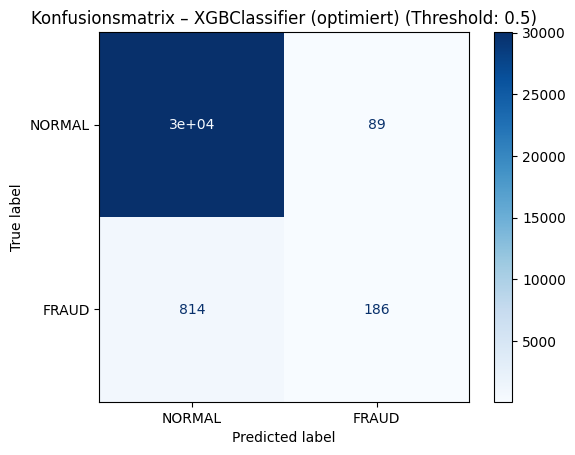


📈 ROC-AUC: 0.8254


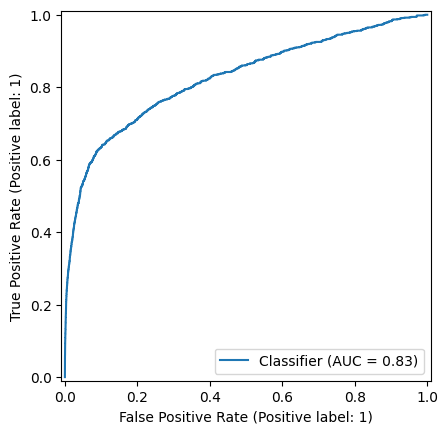

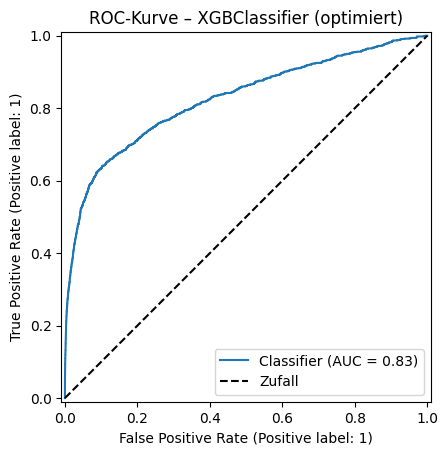

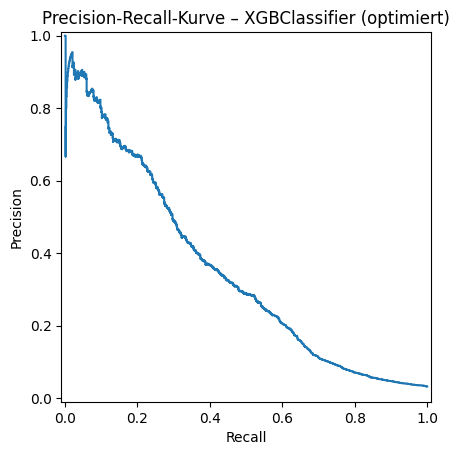


🎯 Wert der Zielfunktion: -6016.79
[LightGBM] [Info] Number of positive: 4000, number of negative: 120553
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2203
[LightGBM] [Info] Number of data points in the train set: 124553, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032115 -> initscore=-3.405795
[LightGBM] [Info] Start training from score -3.405795
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

c:\Users\sofie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.70      0.18      0.29      1000

    accuracy                           0.97     31139
   macro avg       0.84      0.59      0.64     31139
weighted avg       0.96      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30064    75]
 [  821   179]]


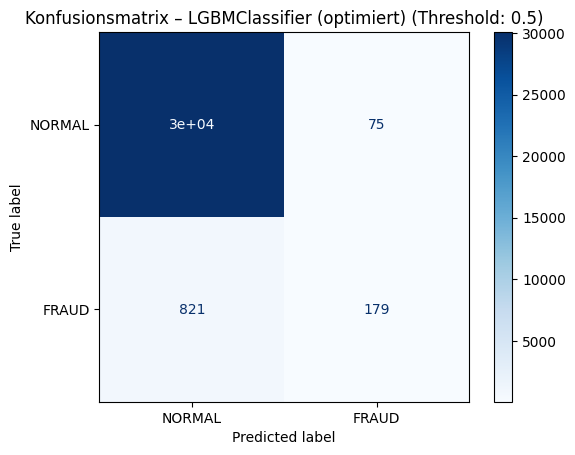


📈 ROC-AUC: 0.8344


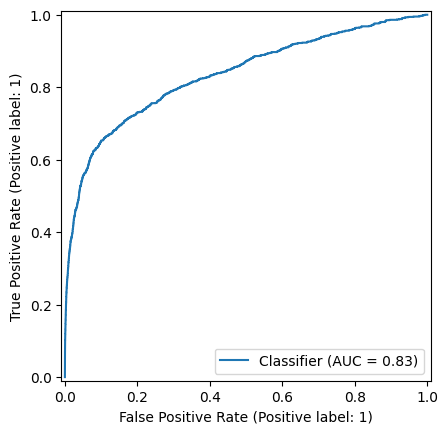

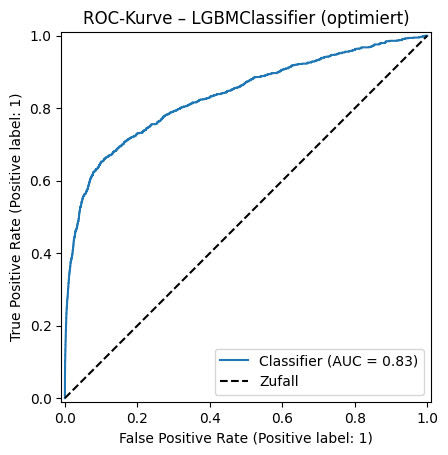

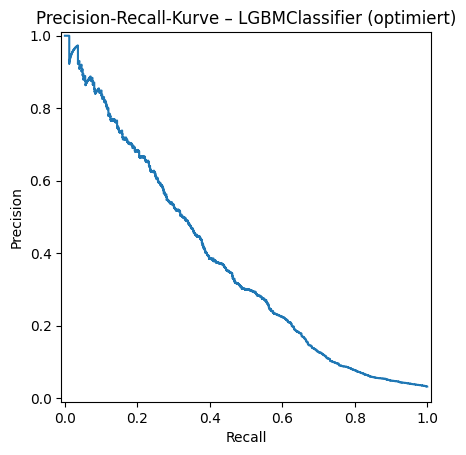


🎯 Wert der Zielfunktion: -5983.90


🔍 Modell: CatBoostClassifier (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.97      1.00      0.99     30139
       FRAUD       0.72      0.19      0.30      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.59      0.64     31139
weighted avg       0.97      0.97      0.96     31139


🔲 Konfusionsmatrix:
[[30067    72]
 [  811   189]]


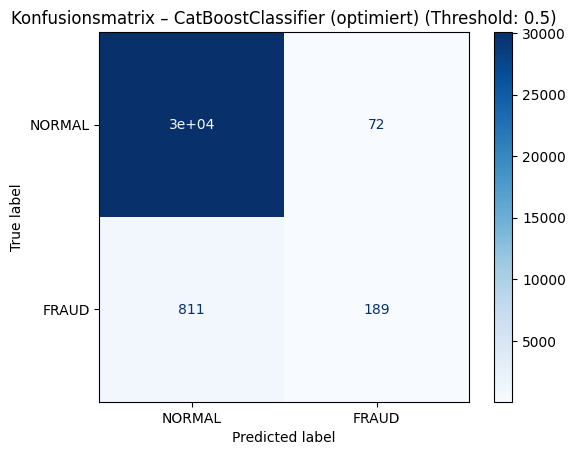


📈 ROC-AUC: 0.8389


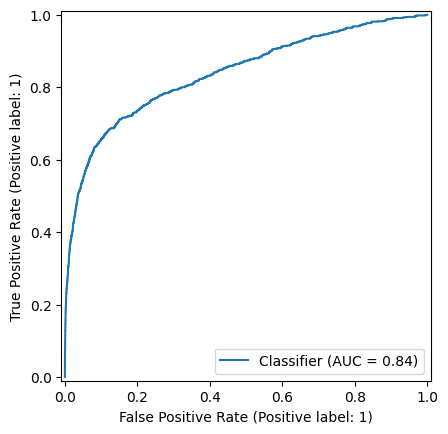

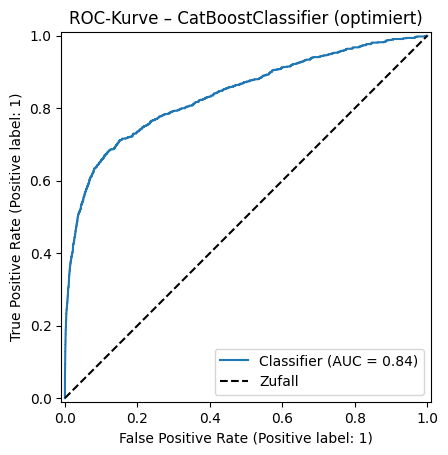

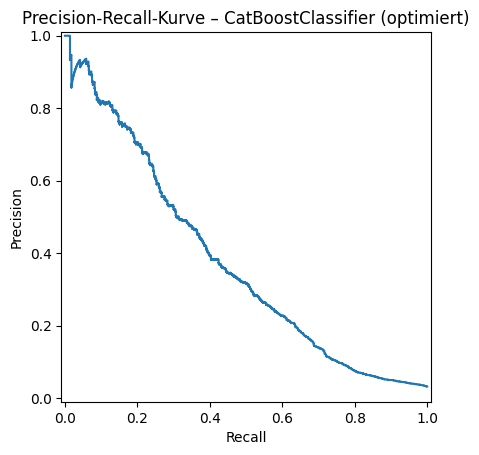


🎯 Wert der Zielfunktion: -5813.55


🔍 Modell: BalancedRandomForestClassifier (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.91      0.95     30139
       FRAUD       0.20      0.64      0.30      1000

    accuracy                           0.90     31139
   macro avg       0.59      0.78      0.62     31139
weighted avg       0.96      0.90      0.93     31139


🔲 Konfusionsmatrix:
[[27543  2596]
 [  363   637]]


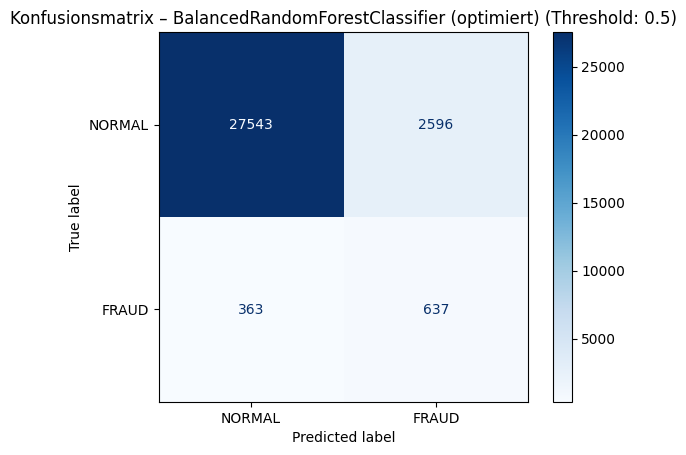


📈 ROC-AUC: 0.8380


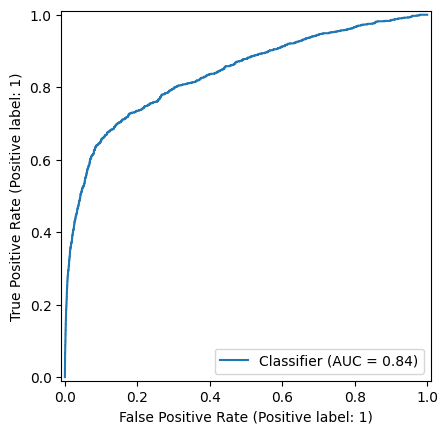

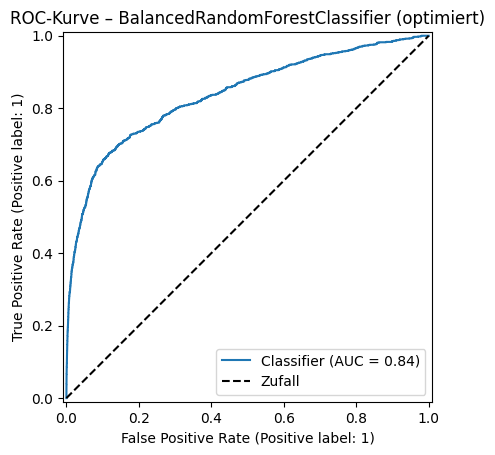

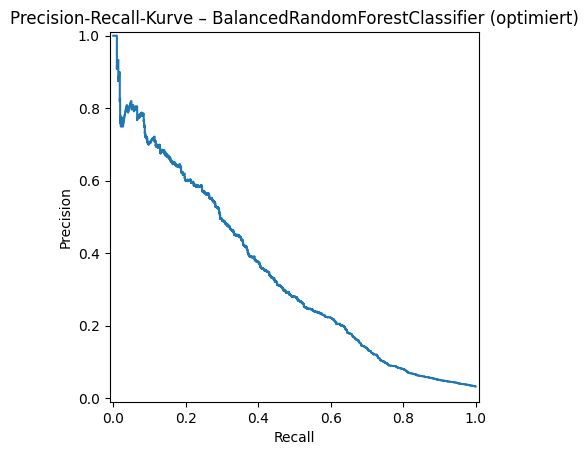


🎯 Wert der Zielfunktion: -25509.09


🔍 Modell: RUSBoostClassifier (optimiert)

📋 Klassifikationsbericht:
              precision    recall  f1-score   support

      NORMAL       0.99      0.92      0.95     30139
       FRAUD       0.20      0.63      0.30      1000

    accuracy                           0.91     31139
   macro avg       0.59      0.77      0.63     31139
weighted avg       0.96      0.91      0.93     31139


🔲 Konfusionsmatrix:
[[27612  2527]
 [  373   627]]


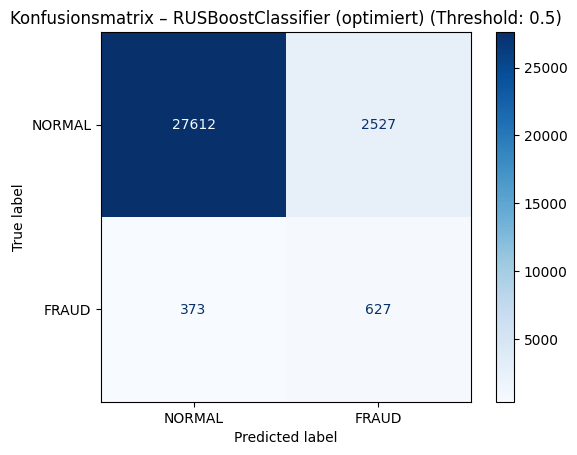


📈 ROC-AUC: 0.8143


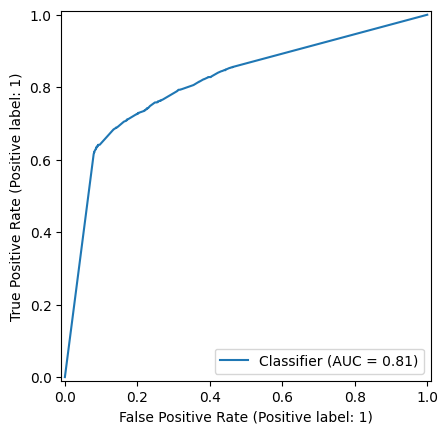

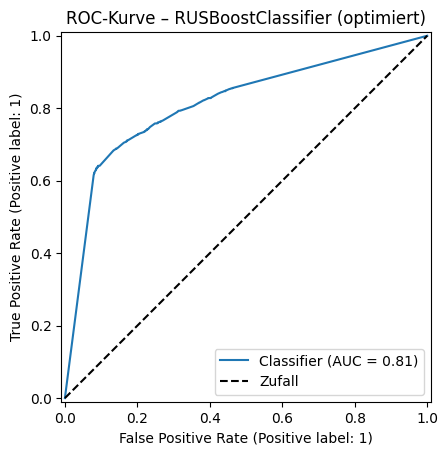

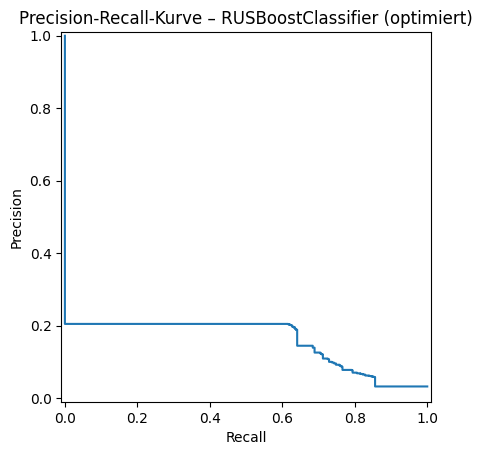


🎯 Wert der Zielfunktion: -24953.73


In [24]:
# Logistic Regression:
best_params_lr = search_lr.best_params_

# Parameter-Mapping von Pipeline auf reines Modell (entfernt 'classifier__')
final_params_lr = {k.replace('classifier__', ''): v for k, v in best_params_lr.items()}

# Modell neu bauen mit besten Parametern
best_model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(**final_params_lr, random_state=42))
])

best_model_lr.fit(X_train, y_train)

# Evaluation wie gewohnt
evaluate_model_with_curves(
    model=best_model_lr.named_steps['classifier'],
    model_name="LogisticRegression (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# RandomForest
best_params_rf = search_rf.best_params_
final_params_rf = {k.replace('classifier__', ''): v for k, v in best_params_rf.items()}
best_model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(**final_params_rf, random_state=42, n_jobs=4))
])
best_model_rf.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_rf.named_steps['classifier'],
    model_name="RandomForestClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# GradientBoosting
best_params_gb = search_gb.best_params_
final_params_gb = {k.replace('classifier__', ''): v for k, v in best_params_gb.items()}
best_model_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(**final_params_gb, random_state=42))
])
best_model_gb.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_gb.named_steps['classifier'],
    model_name="GradientBoostingClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# HistGradientBoosting
best_params_hgb = search_hgb.best_params_
final_params_hgb = {k.replace('classifier__', ''): v for k, v in best_params_hgb.items()}
best_model_hgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(**final_params_hgb, random_state=42))
])
best_model_hgb.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_hgb.named_steps['classifier'],
    model_name="HistGradientBoostingClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# XGBoost
best_params_xgb = search_xgb.best_params_
final_params_xgb = {k.replace('classifier__', ''): v for k, v in best_params_xgb.items()}
best_model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(**final_params_xgb, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=4))
])
best_model_xgb.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_xgb.named_steps['classifier'],
    model_name="XGBClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# LightGBM
best_params_lgbm = search_lgbm.best_params_
final_params_lgbm = {k.replace('classifier__', ''): v for k, v in best_params_lgbm.items()}
best_model_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(**final_params_lgbm, random_state=42, n_jobs=4))
])
best_model_lgbm.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_lgbm.named_steps['classifier'],
    model_name="LGBMClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# CatBoost
best_params_cat = search_cat.best_params_
final_params_cat = {k.replace('classifier__', ''): v for k, v in best_params_cat.items()}
best_model_cat = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(**final_params_cat, verbose=0, random_state=42))
])
best_model_cat.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_cat.named_steps['classifier'],
    model_name="CatBoostClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# BalancedRandomForest
best_params_brf = search_brf.best_params_
final_params_brf = {k.replace('classifier__', ''): v for k, v in best_params_brf.items()}
best_model_brf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(**final_params_brf, random_state=42, n_jobs=4))
])
best_model_brf.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_brf.named_steps['classifier'],
    model_name="BalancedRandomForestClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)

# ========================================================
# RUSBoost
best_params_rus = search_rus.best_params_
final_params_rus = {k.replace('classifier__', ''): v for k, v in best_params_rus.items()}
best_model_rus = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RUSBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), **final_params_rus, random_state=42))
])
best_model_rus.fit(X_train, y_train)

evaluate_model_with_curves(
    model=best_model_rus.named_steps['classifier'],
    model_name="RUSBoostClassifier (optimiert)",
    preprocessor=preprocessor,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    damage_test=damage_test,
    threshold=0.5
)
